# Experimentation for Analyzing W^O Output Projection Matrices for Efficient KV Cache Optimization

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')
from transformers import LlamaModel, AutoTokenizer
import seaborn as sns

def extract_wo_matrices(model):
    """
    Extract W^O matrices from all layers - works with both Llama and Mistral models
    Returns: List of W^O matrices, one per layer
    """
    wo_matrices = []
    
    # Auto-detect model structure
    if hasattr(model, 'layers'):
        # Llama base models
        layers = model.layers
        num_layers = model.config.num_hidden_layers
    elif hasattr(model, 'model') and hasattr(model.model, 'layers'):
        # Mistral and Llama CausalLM models
        layers = model.model.layers
        num_layers = model.config.num_hidden_layers
    else:
        raise ValueError(f"Cannot detect layer structure for {type(model)}")
    
    for layer_idx in range(num_layers):
        # Access the output projection weight from each transformer layer
        wo_weight = layers[layer_idx].self_attn.o_proj.weight
        wo_matrices.append(wo_weight.detach().cpu())
    
    return wo_matrices


def extract_wo_blocks_per_head(wo_matrix, num_heads, head_dim):
    """
    Split W^O matrix into per-head blocks
    wo_matrix: [hidden_size, hidden_size] tensor
    Returns: List of per-head blocks [hidden_size, head_dim]
    """
    blocks = []
    for head_idx in range(num_heads):
        start_idx = head_idx * head_dim
        end_idx = (head_idx + 1) * head_dim
        head_block = wo_matrix[:, start_idx:end_idx]
        blocks.append(head_block)
    
    return blocks

def compute_head_importance_all_layers(model):
    """
    Compute W^O-based importance scores for all heads across all layers
    Works with both Llama and Mistral models
    """
    # Auto-detect model structure
    if hasattr(model, 'layers'):
        layers = model.layers
    elif hasattr(model, 'model') and hasattr(model.model, 'layers'):
        layers = model.model.layers
    else:
        raise ValueError(f"Cannot detect layer structure for {type(model)}")
    
    num_layers = model.config.num_hidden_layers
    num_heads = model.config.num_attention_heads
    head_dim = model.config.hidden_size // num_heads
    
    # Initialize importance matrix [layers, heads]
    importance_matrix = np.zeros((num_layers, num_heads))
    
    for layer_idx in range(num_layers):
        wo_weight = layers[layer_idx].self_attn.o_proj.weight.detach().cpu()
        
        # Extract per-head blocks
        head_blocks = extract_wo_blocks_per_head(wo_weight, num_heads, head_dim)
        
        # Compute Frobenius norm for each head block
        for head_idx, block in enumerate(head_blocks):
            importance_score = torch.norm(block, p='fro').item()
            importance_matrix[layer_idx, head_idx] = importance_score
    
    return importance_matrix


# def plot_head_importance_heatmap(importance_scores, model_name="Model", figsize=(12, 8)):
#     # Additional analysis: Layer-wise statistics
#     layer_avg = importance_scores.mean(axis=1)
#     layer_std = importance_scores.std(axis=1)

#     plt.figure(figsize=(12, 5))

#     plt.subplot(1, 2, 1)
#     plt.plot(range(len(layer_avg)), layer_avg, 'b-o')
#     plt.title('Average Head Importance per Layer')
#     plt.xlabel('Layer Index')
#     plt.ylabel('Average Importance')

#     plt.subplot(1, 2, 2)
#     plt.plot(range(len(layer_std)), layer_std, 'r-o')
#     plt.title('Head Importance Variance per Layer')
#     plt.xlabel('Layer Index')
#     plt.ylabel('Standard Deviation')

#     plt.tight_layout()
#     plt.show()

#     plt.figure(figsize=figsize)
#     sns.heatmap(importance_scores, 
#                 xticklabels=range(importance_scores.shape[1]), 
#                 yticklabels=range(importance_scores.shape[0]),
#                 cmap='viridis',
#                 cbar_kws={'label': 'Importance Score'})
#     plt.title(f'Head Importance Across All Layers ({model_name})')
#     plt.xlabel('Head Index')
#     plt.ylabel('Layer Index')
#     plt.tight_layout()
#     plt.show()
    
#     # Print basic stats
#     print(f"Score range: {importance_scores.min():.3f} to {importance_scores.max():.3f}")
#     print(f"Importance ratio: {importance_scores.max() / importance_scores.min():.2f}x")
    
#     # Top 5 heads
#     print(f"\nTop 5 most important heads:")
#     flat_indices = np.argsort(importance_scores.flatten())[-5:]
#     for idx in reversed(flat_indices):
#         layer_idx, head_idx = np.unravel_index(idx, importance_scores.shape)
#         score = importance_scores[layer_idx, head_idx]
#         print(f"  Layer {layer_idx}, Head {head_idx}: {score:.3f}")

def plot_head_importance_heatmap(importance_scores, model_name="Model", figsize=(18, 12)):
    """
    Combined visualization of head importance heatmap and layer-wise statistics
    """
    layer_avg = importance_scores.mean(axis=1)
    layer_std = importance_scores.std(axis=1)

    # Create figure with custom layout
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 3, width_ratios=[3, 1, 1], height_ratios=[1, 1], hspace=0.3, wspace=0.3)

    # Large heatmap spanning both rows on the left
    ax_heatmap = fig.add_subplot(gs[:, 0])
    sns.heatmap(importance_scores, 
                xticklabels=range(importance_scores.shape[1]), 
                yticklabels=range(importance_scores.shape[0]),
                cmap='viridis',
                cbar_kws={'label': 'Importance Score'},
                ax=ax_heatmap)
    ax_heatmap.set_title(f'Head Importance Across All Layers\n({model_name})', fontsize=14, fontweight='bold')
    ax_heatmap.set_xlabel('Head Index', fontsize=12)
    ax_heatmap.set_ylabel('Layer Index', fontsize=12)

    # Average importance per layer (top right)
    ax_avg = fig.add_subplot(gs[0, 1:])
    ax_avg.plot(range(len(layer_avg)), layer_avg, 'b-o', linewidth=2, markersize=4)
    ax_avg.set_title('Average Head Importance per Layer', fontsize=12, fontweight='bold')
    ax_avg.set_xlabel('Layer Index', fontsize=10)
    ax_avg.set_ylabel('Average Importance', fontsize=10)
    ax_avg.grid(True, alpha=0.3)

    # Variance per layer (bottom right)
    ax_std = fig.add_subplot(gs[1, 1:])
    ax_std.plot(range(len(layer_std)), layer_std, 'r-o', linewidth=2, markersize=4)
    ax_std.set_title('Head Importance Variance per Layer', fontsize=12, fontweight='bold')
    ax_std.set_xlabel('Layer Index', fontsize=10)
    ax_std.set_ylabel('Standard Deviation', fontsize=10)
    ax_std.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print basic stats
    print(f"\n{model_name} Analysis Summary:")
    print(f"Score range: {importance_scores.min():.3f} to {importance_scores.max():.3f}")
    print(f"Importance ratio: {importance_scores.max() / importance_scores.min():.2f}x")
    print(f"Mean importance: {importance_scores.mean():.3f}")
    
    # Layer insights
    print(f"\nLayer-wise insights:")
    print(f"Highest avg layer: Layer {np.argmax(layer_avg)} (avg: {layer_avg.max():.3f})")
    print(f"Most variable layer: Layer {np.argmax(layer_std)} (std: {layer_std.max():.3f})")
    
    # Top 5 heads
    print(f"\nTop 5 most important heads:")
    flat_indices = np.argsort(importance_scores.flatten())[-5:]
    for idx in reversed(flat_indices):
        layer_idx, head_idx = np.unravel_index(idx, importance_scores.shape)
        score = importance_scores[layer_idx, head_idx]
        print(f"  Layer {layer_idx}, Head {head_idx}: {score:.3f}")

/home/am233354/miniconda3/envs/cake_og/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Meta-Llama-3.1-8B-Instruct

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import LlamaModel, AutoTokenizer
import seaborn as sns

# Load the model (you'll need access to meta-llama models)
model_name = "meta-llama/Meta-Llama-3.1-8B-Instruct"
model = LlamaModel.from_pretrained(
    model_name, 
    torch_dtype=torch.bfloat16, 
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)


Loading checkpoint shards: 100%|██████████| 4/4 [00:02<00:00,  1.61it/s]


In [4]:
# Extract all W^O matrices
wo_matrices = extract_wo_matrices(model)

# Print basic information
print(f"Number of layers: {len(wo_matrices)}")
print(f"W^O matrix shape per layer: {wo_matrices[0].shape}")
print(f"Model config - Hidden size: {model.config.hidden_size}")
print(f"Model config - Number of heads: {model.config.num_attention_heads}")


Number of layers: 32
W^O matrix shape per layer: torch.Size([4096, 4096])
Model config - Hidden size: 4096
Model config - Number of heads: 32


In [5]:
# Extract blocks for all layers
num_heads = model.config.num_attention_heads  # 32 for Llama-3.1-8B
head_dim = model.config.hidden_size // num_heads  # 4096 // 32 = 128

all_head_blocks = []
for layer_idx, wo_matrix in enumerate(wo_matrices):
    head_blocks = extract_wo_blocks_per_head(wo_matrix, num_heads, head_dim)
    all_head_blocks.append(head_blocks)
    print(f"Layer {layer_idx}: Extracted {len(head_blocks)} head blocks, each shape {head_blocks[0].shape}")


Layer 0: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 1: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 2: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 3: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 4: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 5: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 6: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 7: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 8: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 9: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 10: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 11: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 12: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 13: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 14: Extrac

In [6]:
# Compute importance scores
importance_scores = compute_head_importance_all_layers(model)
print(f"Importance matrix shape: {importance_scores.shape}")
print(f"Score range: {importance_scores.min():.3f} to {importance_scores.max():.3f}")


Importance matrix shape: (32, 32)
Score range: 3.516 to 12.812


In [8]:
# save the importance scores to a .npy file
import numpy as np
np.save("importance_scores.npy", importance_scores)

/tmp/ipykernel_1217441/966542545.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


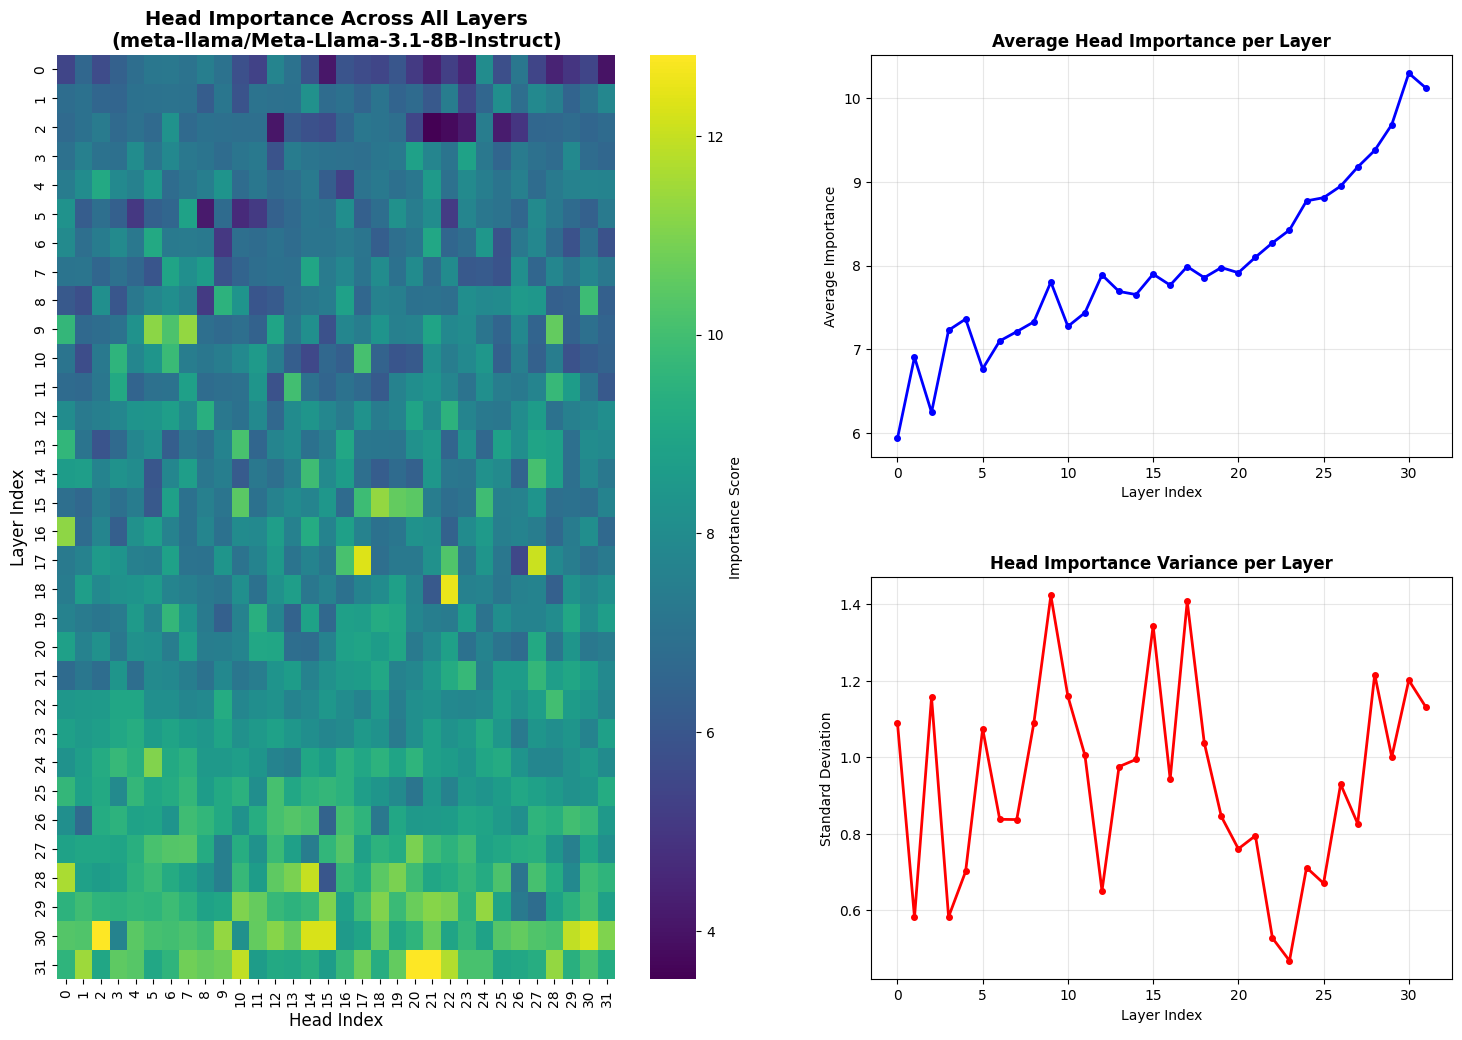


meta-llama/Meta-Llama-3.1-8B-Instruct Analysis Summary:
Score range: 3.516 to 12.812
Importance ratio: 3.64x
Mean importance: 7.975

Layer-wise insights:
Highest avg layer: Layer 30 (avg: 10.295)
Most variable layer: Layer 9 (std: 1.423)

Top 5 most important heads:
  Layer 31, Head 21: 12.812
  Layer 31, Head 20: 12.812
  Layer 30, Head 2: 12.812
  Layer 18, Head 22: 12.500
  Layer 17, Head 17: 12.312


In [7]:
plot_head_importance_heatmap(importance_scores, model_name)

In [16]:
def compute_cosine_similarity_matrix_fixed(wo_matrices, num_heads, head_dim):
    """
    Compute cosine similarity matrix between all W^O blocks across all layers
    Fixes BFloat16 type error by converting to float32
    """
    num_layers = len(wo_matrices)
    total_heads = num_layers * num_heads
    
    # Flatten all blocks into vectors
    blocks = []
    for layer_idx, wo_matrix in enumerate(wo_matrices):
        for head_idx in range(num_heads):
            start_idx = head_idx * head_dim
            end_idx = (head_idx + 1) * head_dim
            block = wo_matrix[:, start_idx:end_idx].to(torch.float32)  # Convert to float32
            blocks.append(block.flatten())
    
    # Stack into tensor
    blocks_tensor = torch.stack(blocks)  # shape: [total_heads, hidden_size * head_dim]
    
    # Normalize for cosine similarity
    blocks_norm = blocks_tensor / blocks_tensor.norm(dim=1, keepdim=True)
    
    # Compute cosine similarity matrix
    similarity_matrix = blocks_norm @ blocks_norm.T
    
    return similarity_matrix.to(torch.float32).numpy(), num_layers, num_heads  # Ensure float32 before numpy()

# Use the fixed function
similarity_matrix, num_layers_sim, num_heads_sim = compute_cosine_similarity_matrix_fixed(wo_matrices, num_heads, head_dim)


# Find highly similar head pairs across layers
def find_similar_heads_cross_layer(similarity_matrix, num_layers, num_heads, threshold=0.6):
    similar_pairs = []
    total_heads = num_layers * num_heads
    
    for i in range(total_heads):
        for j in range(i+1, total_heads):
            if similarity_matrix[i, j] > threshold:
                layer_i, head_i = divmod(i, num_heads)
                layer_j, head_j = divmod(j, num_heads)
                similar_pairs.append({
                    'layer1': layer_i, 'head1': head_i,
                    'layer2': layer_j, 'head2': head_j,
                    'similarity': similarity_matrix[i, j]
                })
    
    return similar_pairs

similar_heads = find_similar_heads_cross_layer(similarity_matrix, len(wo_matrices), num_heads)
print(f"Found {len(similar_heads)} highly similar head pairs across layers")


Found 5 highly similar head pairs across layers


# llama2-7b-chat-4k

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.44it/s]


Number of layers: 32
W^O matrix shape per layer: torch.Size([4096, 4096])
Model config - Hidden size: 4096
Model config - Number of heads: 32
Importance matrix shape: (32, 32)
Score range: 3.062 to 21.125


/tmp/ipykernel_1250078/966542545.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


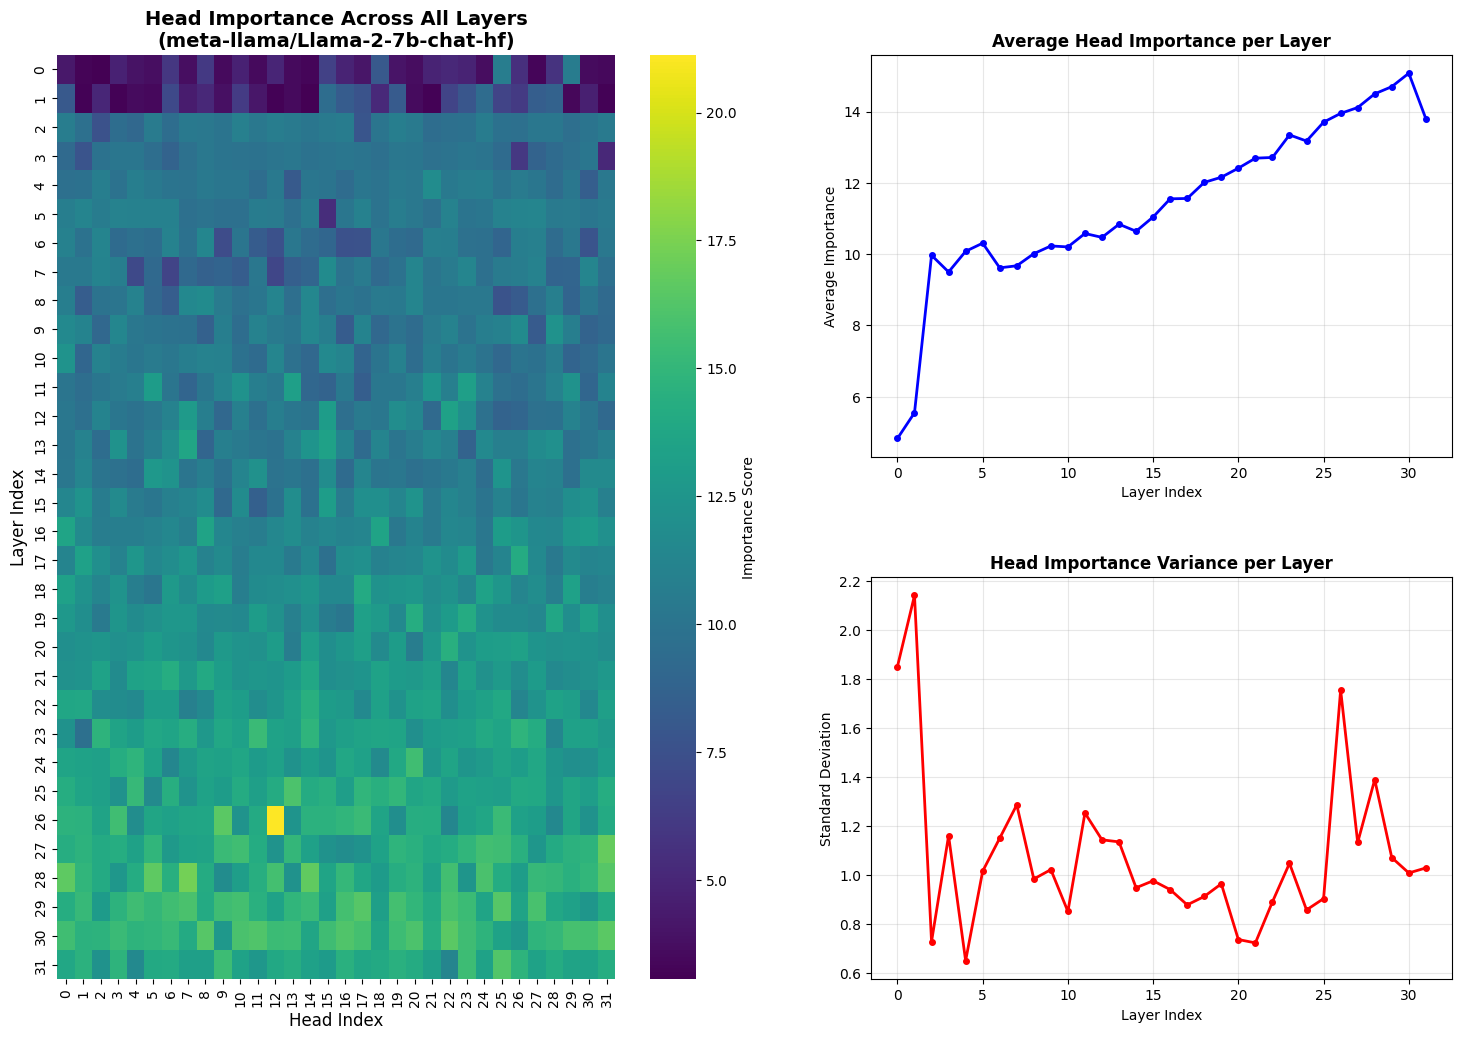


meta-llama/Llama-2-7b-chat-hf Analysis Summary:
Score range: 3.062 to 21.125
Importance ratio: 6.90x
Mean importance: 11.405

Layer-wise insights:
Highest avg layer: Layer 30 (avg: 15.074)
Most variable layer: Layer 1 (std: 2.142)

Top 5 most important heads:
  Layer 26, Head 12: 21.125
  Layer 28, Head 7: 17.250
  Layer 27, Head 31: 16.875
  Layer 28, Head 14: 16.750
  Layer 28, Head 5: 16.625


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import LlamaModel, AutoTokenizer
import seaborn as sns

model_name = "meta-llama/Llama-2-7b-chat-hf"
model = LlamaModel.from_pretrained(
    model_name, 
    torch_dtype=torch.bfloat16, 
    device_map="cpu"
)
#tokenizer = AutoTokenizer.from_pretrained(model_name)

# Extract all W^O matrices
wo_matrices = extract_wo_matrices(model)

# Print basic information
print(f"Number of layers: {len(wo_matrices)}")
print(f"W^O matrix shape per layer: {wo_matrices[0].shape}")
print(f"Model config - Hidden size: {model.config.hidden_size}")
print(f"Model config - Number of heads: {model.config.num_attention_heads}")

# Extract blocks for all layers
num_heads = model.config.num_attention_heads  # 32 for Llama-3.1-8B
head_dim = model.config.hidden_size // num_heads  # 4096 // 32 = 128

all_head_blocks = []
for layer_idx, wo_matrix in enumerate(wo_matrices):
    head_blocks = extract_wo_blocks_per_head(wo_matrix, num_heads, head_dim)
    all_head_blocks.append(head_blocks)
    # print(f"Layer {layer_idx}: Extracted {len(head_blocks)} head blocks, each shape {head_blocks[0].shape}")

# Compute importance scores
importance_scores = compute_head_importance_all_layers(model)
print(f"Importance matrix shape: {importance_scores.shape}")
print(f"Score range: {importance_scores.min():.3f} to {importance_scores.max():.3f}")

plot_head_importance_heatmap(importance_scores, model_name)

In [3]:
importance_scores.shape

(32, 32)

In [4]:
import numpy as np
np.save("meta_llama_2_7b_chat_importance.npy", importance_scores)

Loading checkpoint shards: 100%|██████████| 3/3 [00:02<00:00,  1.36it/s]


Number of layers: 40
W^O matrix shape per layer: torch.Size([5120, 5120])
Model config - Hidden size: 5120
Model config - Number of heads: 40
Importance matrix shape: (40, 40)
Score range: 3.797 to 25.750


/tmp/ipykernel_1250078/966542545.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


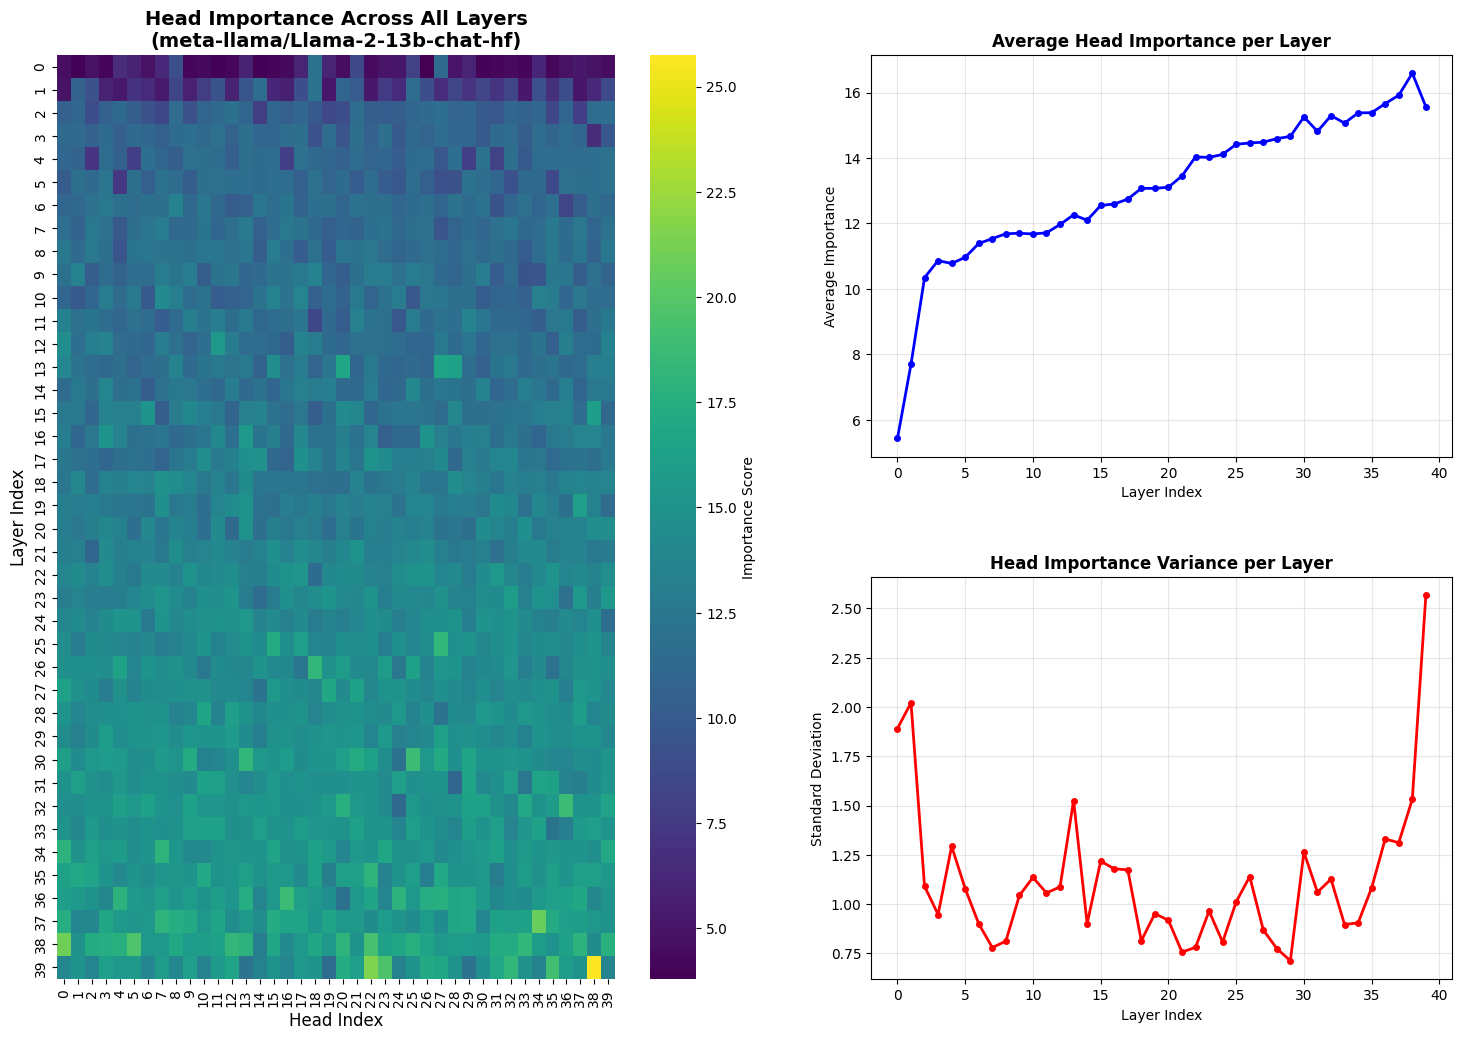


meta-llama/Llama-2-13b-chat-hf Analysis Summary:
Score range: 3.797 to 25.750
Importance ratio: 6.78x
Mean importance: 13.059

Layer-wise insights:
Highest avg layer: Layer 38 (avg: 16.591)
Most variable layer: Layer 39 (std: 2.566)

Top 5 most important heads:
  Layer 39, Head 38: 25.750
  Layer 39, Head 22: 21.500
  Layer 38, Head 0: 20.875
  Layer 37, Head 34: 20.750
  Layer 38, Head 5: 19.625


In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import LlamaModel, AutoTokenizer
import seaborn as sns

model_name = "meta-llama/Llama-2-13b-chat-hf"
model = LlamaModel.from_pretrained(
    model_name, 
    torch_dtype=torch.bfloat16, 
    device_map="cpu"
)
#tokenizer = AutoTokenizer.from_pretrained(model_name)

# Extract all W^O matrices
wo_matrices = extract_wo_matrices(model)

# Print basic information
print(f"Number of layers: {len(wo_matrices)}")
print(f"W^O matrix shape per layer: {wo_matrices[0].shape}")
print(f"Model config - Hidden size: {model.config.hidden_size}")
print(f"Model config - Number of heads: {model.config.num_attention_heads}")

# Extract blocks for all layers
num_heads = model.config.num_attention_heads  # 32 for Llama-3.1-8B
head_dim = model.config.hidden_size // num_heads  # 4096 // 32 = 128

all_head_blocks = []
for layer_idx, wo_matrix in enumerate(wo_matrices):
    head_blocks = extract_wo_blocks_per_head(wo_matrix, num_heads, head_dim)
    all_head_blocks.append(head_blocks)
    # print(f"Layer {layer_idx}: Extracted {len(head_blocks)} head blocks, each shape {head_blocks[0].shape}")

# Compute importance scores
importance_scores = compute_head_importance_all_layers(model)
print(f"Importance matrix shape: {importance_scores.shape}")
print(f"Score range: {importance_scores.min():.3f} to {importance_scores.max():.3f}")

plot_head_importance_heatmap(importance_scores, model_name)

In [6]:
import numpy as np
np.save("meta_llama_2_13b_chat_importance.npy", importance_scores)

## Mistral

In [40]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
import seaborn as sns

# Load Mistral model from Hugging Face
model_name = "mistralai/Mistral-7B-Instruct-v0.3"
model = AutoModelForCausalLM.from_pretrained(
    model_name, 
    torch_dtype=torch.bfloat16, 
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards: 100%|██████████| 3/3 [00:02<00:00,  1.11it/s]


Number of layers: 32
W^O matrix shape per layer: torch.Size([4096, 4096])
Model config - Hidden size: 4096
Model config - Number of heads: 32
Importance matrix shape: (32, 32)
Score range: 0.734 to 3.547


/tmp/ipykernel_4039034/1207373554.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


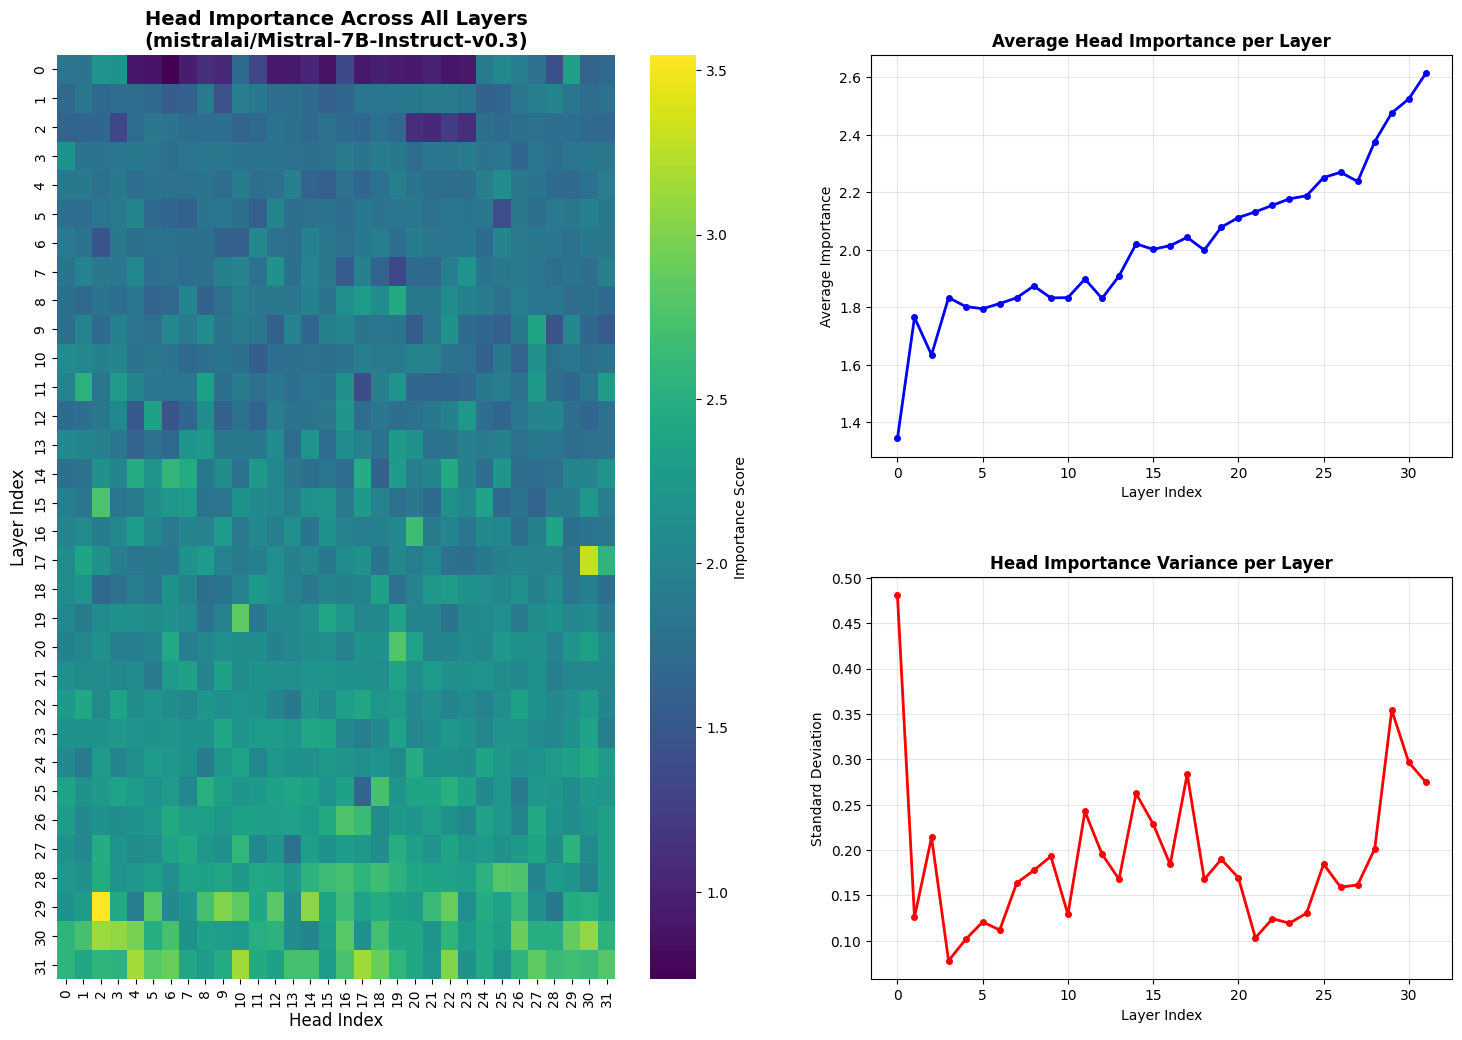


mistralai/Mistral-7B-Instruct-v0.3 Analysis Summary:
Score range: 0.734 to 3.547
Importance ratio: 4.83x
Mean importance: 2.021

Layer-wise insights:
Highest avg layer: Layer 31 (avg: 2.614)
Most variable layer: Layer 0 (std: 0.480)

Top 5 most important heads:
  Layer 29, Head 2: 3.547
  Layer 17, Head 30: 3.297
  Layer 31, Head 4: 3.172
  Layer 31, Head 10: 3.141
  Layer 31, Head 17: 3.141


In [43]:
# Extract all W^O matrices
wo_matrices = extract_wo_matrices(model)

# Print basic information
print(f"Number of layers: {len(wo_matrices)}")
print(f"W^O matrix shape per layer: {wo_matrices[0].shape}")
print(f"Model config - Hidden size: {model.config.hidden_size}")
print(f"Model config - Number of heads: {model.config.num_attention_heads}")

# Extract blocks for all layers
num_heads = model.config.num_attention_heads  # 32 for Llama-3.1-8B
head_dim = model.config.hidden_size // num_heads  # 4096 // 32 = 128

all_head_blocks = []
for layer_idx, wo_matrix in enumerate(wo_matrices):
    head_blocks = extract_wo_blocks_per_head(wo_matrix, num_heads, head_dim)
    all_head_blocks.append(head_blocks)
    # print(f"Layer {layer_idx}: Extracted {len(head_blocks)} head blocks, each shape {head_blocks[0].shape}")

# Compute importance scores
importance_scores = compute_head_importance_all_layers(model)
print(f"Importance matrix shape: {importance_scores.shape}")
print(f"Score range: {importance_scores.min():.3f} to {importance_scores.max():.3f}")

plot_head_importance_heatmap(importance_scores, model_name)

## Llama 70B

Loading checkpoint shards:  77%|███████▋  | 23/30 [00:01<00:00, 13.08it/s]

Loading checkpoint shards: 100%|██████████| 30/30 [00:02<00:00, 11.85it/s]


Number of layers: 80
W^O matrix shape per layer: torch.Size([8192, 8192])
Model config - Hidden size: 8192
Model config - Number of heads: 64
Importance matrix shape: (80, 64)
Score range: 4.438 to 20.125


/tmp/ipykernel_24675/966542545.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


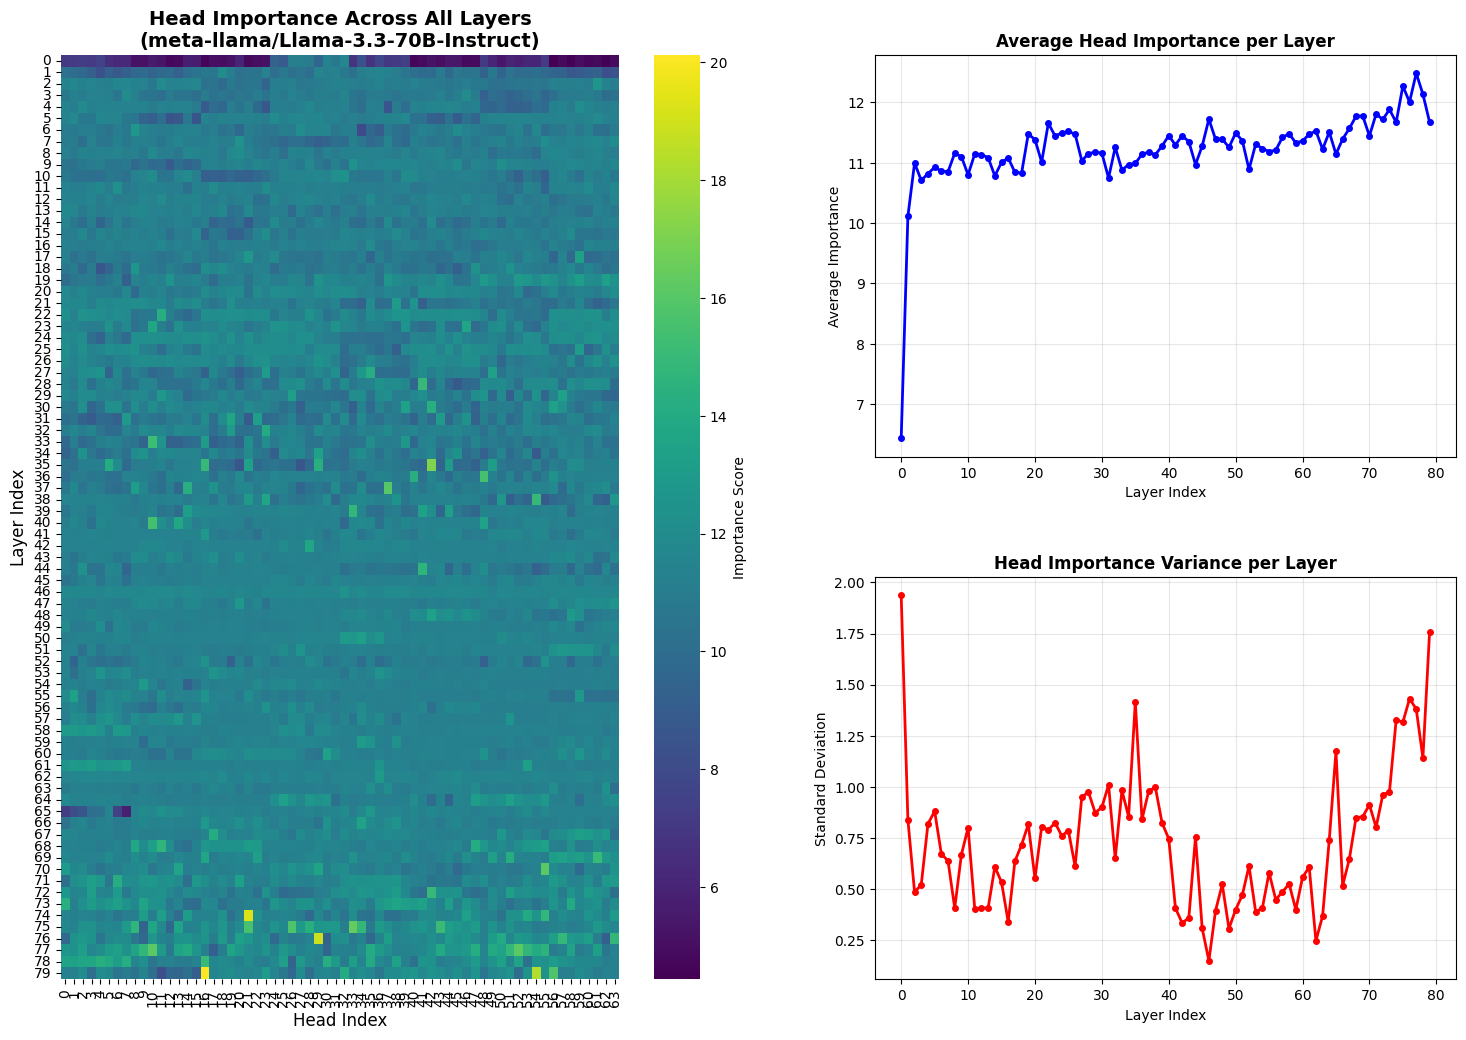


meta-llama/Llama-3.3-70B-Instruct Analysis Summary:
Score range: 4.438 to 20.125
Importance ratio: 4.54x
Mean importance: 11.231

Layer-wise insights:
Highest avg layer: Layer 77 (avg: 12.482)
Most variable layer: Layer 0 (std: 1.936)

Top 5 most important heads:
  Layer 79, Head 16: 20.125
  Layer 74, Head 21: 19.250
  Layer 76, Head 29: 18.875
  Layer 79, Head 54: 18.250
  Layer 35, Head 42: 17.125


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import LlamaModel, AutoTokenizer
import seaborn as sns

model_name = "meta-llama/Llama-3.3-70B-Instruct"
model = LlamaModel.from_pretrained(
    model_name, 
    torch_dtype=torch.bfloat16, 
    device_map="cpu"
)
#tokenizer = AutoTokenizer.from_pretrained(model_name)

# Extract all W^O matrices
wo_matrices = extract_wo_matrices(model)

# Print basic information
print(f"Number of layers: {len(wo_matrices)}")
print(f"W^O matrix shape per layer: {wo_matrices[0].shape}")
print(f"Model config - Hidden size: {model.config.hidden_size}")
print(f"Model config - Number of heads: {model.config.num_attention_heads}")

# Extract blocks for all layers
num_heads = model.config.num_attention_heads  # 32 for Llama-3.1-8B
head_dim = model.config.hidden_size // num_heads  # 4096 // 32 = 128

all_head_blocks = []
for layer_idx, wo_matrix in enumerate(wo_matrices):
    head_blocks = extract_wo_blocks_per_head(wo_matrix, num_heads, head_dim)
    all_head_blocks.append(head_blocks)
    # print(f"Layer {layer_idx}: Extracted {len(head_blocks)} head blocks, each shape {head_blocks[0].shape}")

# Compute importance scores
importance_scores = compute_head_importance_all_layers(model)
print(f"Importance matrix shape: {importance_scores.shape}")
print(f"Score range: {importance_scores.min():.3f} to {importance_scores.max():.3f}")

plot_head_importance_heatmap(importance_scores, model_name)

## Qwen2.5-14B-Instruct-1M

Loading checkpoint shards: 100%|██████████| 8/8 [00:00<00:00, 12.68it/s]


Number of layers: 48
W^O matrix shape per layer: torch.Size([5120, 5120])
Model config - Hidden size: 5120
Model config - Number of heads: 40
Importance matrix shape: (48, 40)
Score range: 6.000 to 27.250


/tmp/ipykernel_46740/966542545.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


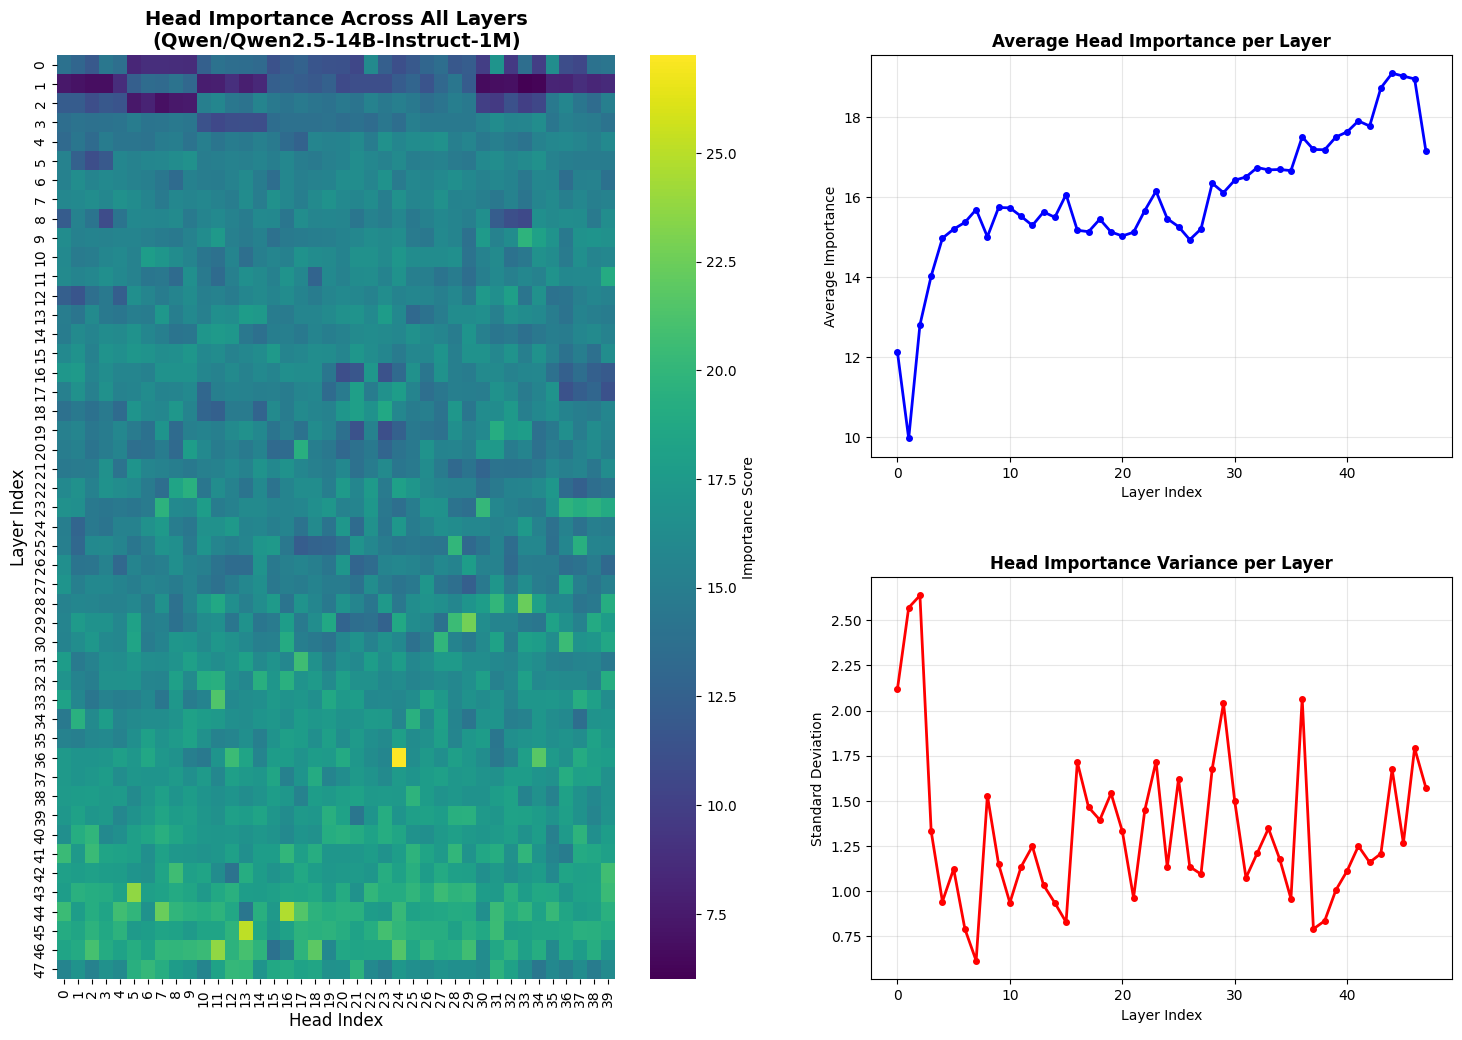


Qwen/Qwen2.5-14B-Instruct-1M Analysis Summary:
Score range: 6.000 to 27.250
Importance ratio: 4.54x
Mean importance: 15.963

Layer-wise insights:
Highest avg layer: Layer 44 (avg: 19.094)
Most variable layer: Layer 2 (std: 2.638)

Top 5 most important heads:
  Layer 36, Head 24: 27.250
  Layer 45, Head 13: 25.125
  Layer 44, Head 16: 24.750
  Layer 43, Head 5: 23.750
  Layer 46, Head 11: 23.750


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
import seaborn as sns

model_name = "Qwen/Qwen2.5-14B-Instruct-1M"
model = AutoModelForCausalLM.from_pretrained(
    model_name, 
    torch_dtype=torch.bfloat16, 
    device_map="cpu"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Extract all W^O matrices
wo_matrices = extract_wo_matrices(model)

# Print basic information
print(f"Number of layers: {len(wo_matrices)}")
print(f"W^O matrix shape per layer: {wo_matrices[0].shape}")
print(f"Model config - Hidden size: {model.config.hidden_size}")
print(f"Model config - Number of heads: {model.config.num_attention_heads}")

# Extract blocks for all layers
num_heads = model.config.num_attention_heads  # 32 for Llama-3.1-8B
head_dim = model.config.hidden_size // num_heads  # 4096 // 32 = 128

all_head_blocks = []
for layer_idx, wo_matrix in enumerate(wo_matrices):
    head_blocks = extract_wo_blocks_per_head(wo_matrix, num_heads, head_dim)
    all_head_blocks.append(head_blocks)
    # print(f"Layer {layer_idx}: Extracted {len(head_blocks)} head blocks, each shape {head_blocks[0].shape}")

# Compute importance scores
importance_scores = compute_head_importance_all_layers(model)
print(f"Importance matrix shape: {importance_scores.shape}")
print(f"Score range: {importance_scores.min():.3f} to {importance_scores.max():.3f}")

plot_head_importance_heatmap(importance_scores, model_name)

## Deepseek R1 Reasoning Model
Does the learned matrix work differently for reasoning models?

Loading checkpoint shards: 100%|██████████| 8/8 [00:00<00:00, 12.44it/s]


Number of layers: 64
W^O matrix shape per layer: torch.Size([5120, 5120])
Model config - Hidden size: 5120
Model config - Number of heads: 40
Importance matrix shape: (64, 40)
Score range: 9.375 to 42.250


/tmp/ipykernel_49843/966542545.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


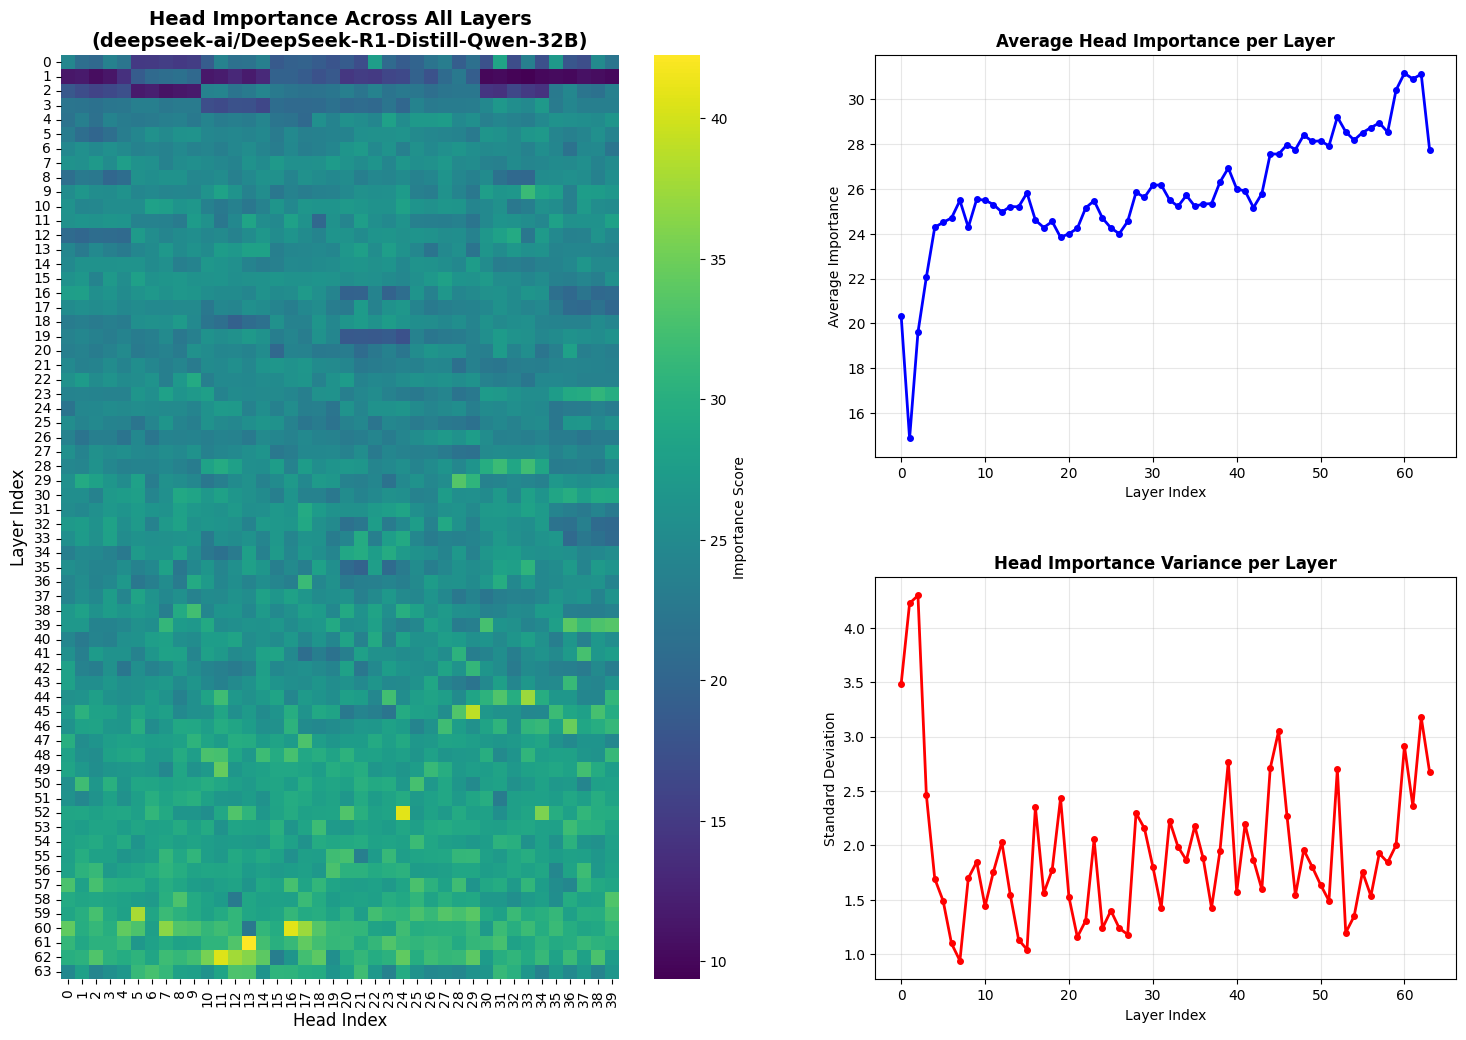


deepseek-ai/DeepSeek-R1-Distill-Qwen-32B Analysis Summary:
Score range: 9.375 to 42.250
Importance ratio: 4.51x
Mean importance: 25.919

Layer-wise insights:
Highest avg layer: Layer 60 (avg: 31.153)
Most variable layer: Layer 2 (std: 4.295)

Top 5 most important heads:
  Layer 61, Head 13: 42.250
  Layer 60, Head 16: 40.750
  Layer 52, Head 24: 40.750
  Layer 62, Head 11: 40.500
  Layer 45, Head 29: 39.000


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
import seaborn as sns

model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-32B"
model = AutoModelForCausalLM.from_pretrained(
    model_name, 
    torch_dtype=torch.bfloat16, 
    device_map="cpu"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Extract all W^O matrices
wo_matrices = extract_wo_matrices(model)

# Print basic information
print(f"Number of layers: {len(wo_matrices)}")
print(f"W^O matrix shape per layer: {wo_matrices[0].shape}")
print(f"Model config - Hidden size: {model.config.hidden_size}")
print(f"Model config - Number of heads: {model.config.num_attention_heads}")

# Extract blocks for all layers
num_heads = model.config.num_attention_heads  # 32 for Llama-3.1-8B
head_dim = model.config.hidden_size // num_heads  # 4096 // 32 = 128

all_head_blocks = []
for layer_idx, wo_matrix in enumerate(wo_matrices):
    head_blocks = extract_wo_blocks_per_head(wo_matrix, num_heads, head_dim)
    all_head_blocks.append(head_blocks)
    # print(f"Layer {layer_idx}: Extracted {len(head_blocks)} head blocks, each shape {head_blocks[0].shape}")

# Compute importance scores
importance_scores = compute_head_importance_all_layers(model)
print(f"Importance matrix shape: {importance_scores.shape}")
print(f"Score range: {importance_scores.min():.3f} to {importance_scores.max():.3f}")

plot_head_importance_heatmap(importance_scores, model_name)

## Qwen2.5-1.5B-Instruct

Number of layers: 28
W^O matrix shape per layer: torch.Size([1536, 1536])
Model config - Hidden size: 1536
Model config - Number of heads: 12
Importance matrix shape: (28, 12)
Score range: 6.469 to 19.500


/tmp/ipykernel_61865/966542545.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


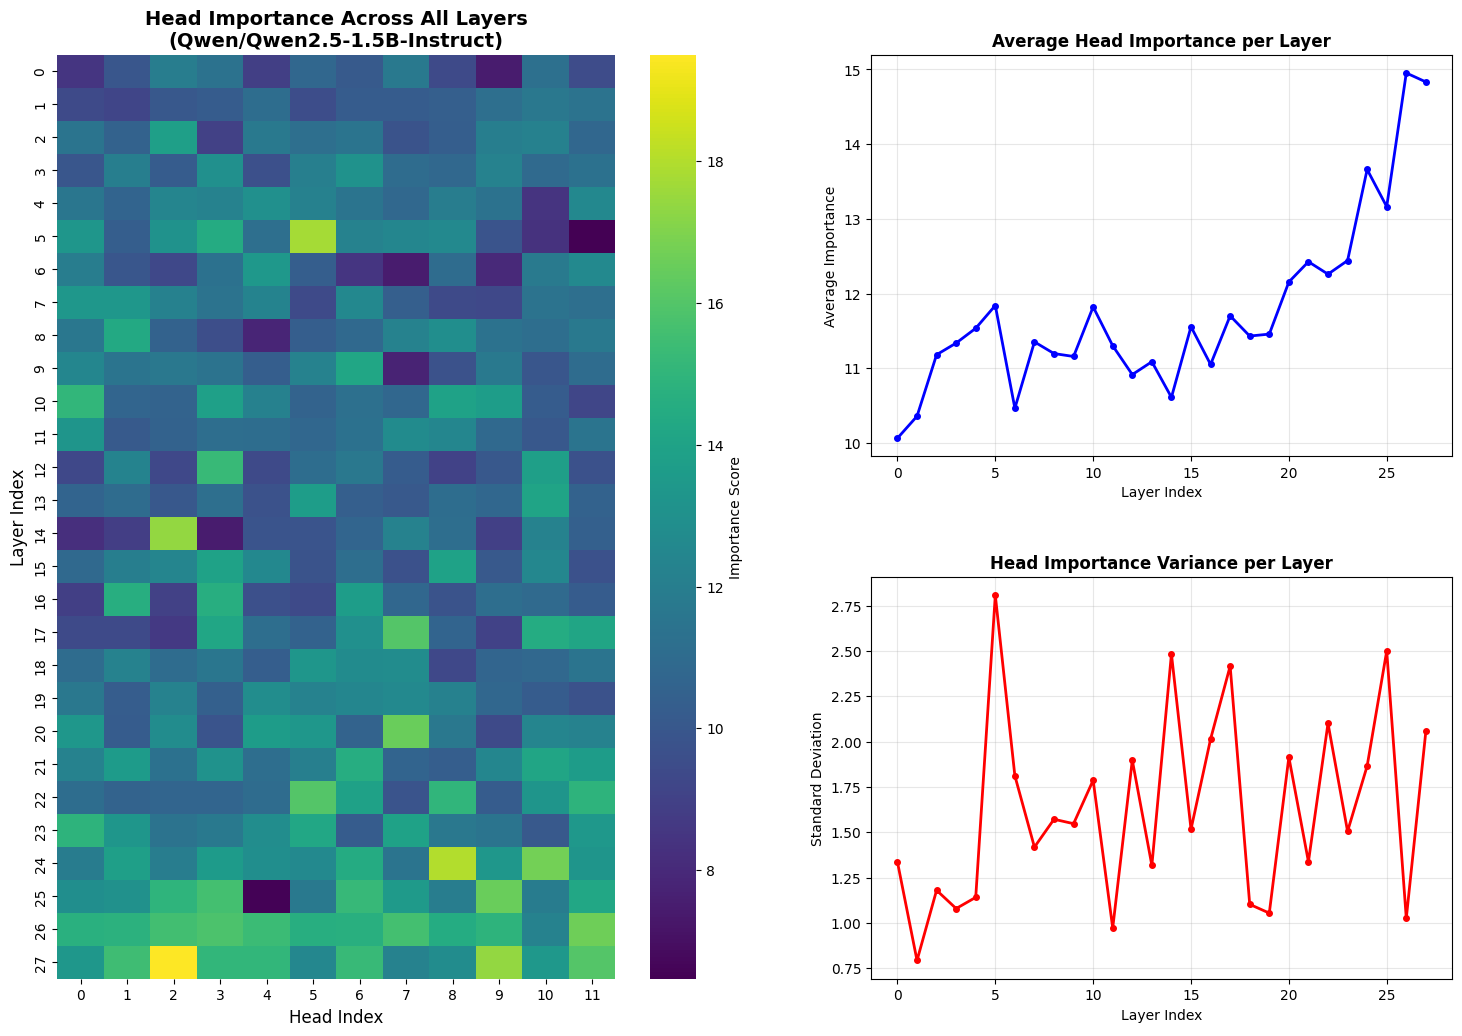


Qwen/Qwen2.5-1.5B-Instruct Analysis Summary:
Score range: 6.469 to 19.500
Importance ratio: 3.01x
Mean importance: 11.762

Layer-wise insights:
Highest avg layer: Layer 26 (avg: 14.953)
Most variable layer: Layer 5 (std: 2.807)

Top 5 most important heads:
  Layer 27, Head 2: 19.500
  Layer 24, Head 8: 18.000
  Layer 5, Head 5: 17.750
  Layer 14, Head 2: 17.375
  Layer 27, Head 9: 17.375


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
import seaborn as sns

model_name = "Qwen/Qwen2.5-1.5B-Instruct"
model = AutoModelForCausalLM.from_pretrained(
    model_name, 
    torch_dtype=torch.bfloat16, 
    device_map="cpu"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Extract all W^O matrices
wo_matrices = extract_wo_matrices(model)

# Print basic information
print(f"Number of layers: {len(wo_matrices)}")
print(f"W^O matrix shape per layer: {wo_matrices[0].shape}")
print(f"Model config - Hidden size: {model.config.hidden_size}")
print(f"Model config - Number of heads: {model.config.num_attention_heads}")

# Extract blocks for all layers
num_heads = model.config.num_attention_heads  # 32 for Llama-3.1-8B
head_dim = model.config.hidden_size // num_heads  # 4096 // 32 = 128

all_head_blocks = []
for layer_idx, wo_matrix in enumerate(wo_matrices):
    head_blocks = extract_wo_blocks_per_head(wo_matrix, num_heads, head_dim)
    all_head_blocks.append(head_blocks)
    # print(f"Layer {layer_idx}: Extracted {len(head_blocks)} head blocks, each shape {head_blocks[0].shape}")

# Compute importance scores
importance_scores = compute_head_importance_all_layers(model)
print(f"Importance matrix shape: {importance_scores.shape}")
print(f"Score range: {importance_scores.min():.3f} to {importance_scores.max():.3f}")

plot_head_importance_heatmap(importance_scores, model_name)

In [59]:
import gc
import torch

# More aggressive cleanup for Jupyter
def clear_memory_jupyter():
    # Clear all variables from global namespace
    for var in list(globals().keys()):
        if not var.startswith('_') and var not in ['gc', 'torch', 'clear_memory_jupyter']:
            try:
                del globals()[var]
            except:
                pass
    
    # Force garbage collection multiple times
    for _ in range(3):
        gc.collect()
    
    # Clear GPU cache aggressively
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        torch.cuda.ipc_collect()  # Additional cleanup
    
    print("Aggressive memory cleanup completed")

# Use this instead of just del model
clear_memory_jupyter()


Aggressive memory cleanup completed


In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"  # or your local one
model = AutoModelForCausalLM.from_pretrained(model_id).cuda()
tokenizer = AutoTokenizer.from_pretrained(model_id)

inputs = tokenizer("The capital city of France is: ", return_tensors="pt").to("cuda")
outputs = model.generate(**inputs, max_new_tokens=10)
print(tokenizer.decode(outputs[0]))


/home/am233354/miniconda3/envs/cake_og/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading checkpoint shards: 100%|██████████| 4/4 [00:01<00:00,  2.36it/s]


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


<|begin_of_text|>The capital city of France is: 1) Paris 2) Lyon 3)


In [1]:
import os
import json

def append_average_to_all_latency_files_recursive(root_dir):
    for dirpath, _, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith('_latencies.jsonl'):
                filepath = os.path.join(dirpath, filename)
                print(f"Processing {filepath}")
                latencies = []
                with open(filepath, 'r', encoding='utf-8') as f:
                    for line in f:
                        entry = json.loads(line.strip())
                        if isinstance(entry.get("latency"), (float, int)):
                            latencies.append(entry['latency'])

                if not latencies:
                    print(f"No valid latency entries found in {filepath}")
                    continue

                average_latency = sum(latencies) / len(latencies)
                average_entry = {"sample_num": "average", "latency": average_latency}

                with open(filepath, 'a', encoding='utf-8') as f:
                    f.write(json.dumps(average_entry) + '\n')

                print(f"Appended average latency {average_latency:.4f} to {filepath}")

# Usage:
# Set 'root_dir' to the root of your experiment folder tree (e.g., "./pred_result").
append_average_to_all_latency_files_recursive("./pred_result")


Processing ./pred_result/cache1024/Matrix_Headwise_Latency/llama3.1-8b-128k/narrativeqa_latencies.jsonl
Appended average latency 7.6430 to ./pred_result/cache1024/Matrix_Headwise_Latency/llama3.1-8b-128k/narrativeqa_latencies.jsonl
Processing ./pred_result/cache1024/Matrix_Headwise_Latency/llama3.1-8b-128k/samsum_latencies.jsonl
Appended average latency 9.6702 to ./pred_result/cache1024/Matrix_Headwise_Latency/llama3.1-8b-128k/samsum_latencies.jsonl
Processing ./pred_result/cache1024/Matrix_Headwise_Latency/llama3.1-8b-128k/multi_news_latencies.jsonl
Appended average latency 17.6944 to ./pred_result/cache1024/Matrix_Headwise_Latency/llama3.1-8b-128k/multi_news_latencies.jsonl
Processing ./pred_result/cache1024/Matrix_Headwise_Latency/llama3.1-8b-128k/hotpotqa_latencies.jsonl
Appended average latency 3.3988 to ./pred_result/cache1024/Matrix_Headwise_Latency/llama3.1-8b-128k/hotpotqa_latencies.jsonl
Processing ./pred_result/cache1024/Matrix_latency_test/llama3.1-8b-128k/narrativeqa_laten

In [5]:
import pandas as pd 
import matplotlib.pyplot as plt
plt.style.use('default')

In [10]:
datasets = [
    "NrtvQA", "Qasper", "MF-en", "HotpotQA", "2WikiMQA", "Musique",
    "GovReport", "QMSum", "MultiNews", "TREC", "TriviaQA", "SAMSum",
    "PCount", "PR-en", "Lcc", "RB-P", "Avg."
]

# Example: accuracy across datasets for two methods
data = {
'full_attn' : [30.96, 45.49, 53.78, 55.04, 47.14, 31.42, 34.88, 25.29, 27.55, 72.5, 91.65, 43.67, 6, 99.5, 63.19, 56.56, 49.04],

'cake_1024' : [30.88, 44.95, 52.38, 55.49, 46.99, 30.82, 28.68, 24.91, 26.39, 69, 91.94, 42.6, 6, 99.5, 62.65, 56.89, 48.13],
'static_1024' : [29.84, 45.93, 53.78, 55.04, 46.63, 30.92, 34.64, 25.35, 27.52, 73, 91.65, 43.53, 6, 99.5, 63.33, 56.34, 48.94],
'PyramidKV_1024' : [30.54, 43.64, 52.73, 55.29, 46.29, 31.28, 27.53, 24.50, 26.00, 68.00, 92.09, 41.75, 6.05, 99.50, 62.35, 55.44, 47.69],
'SnapKV_1024' : [30.95, 44.74, 52.58, 55.09, 46.83, 30.37, 27.87, 24.57, 25.99, 68.00, 92.03, 42.60, 6.50, 99.50, 63.00, 56.50, 47.95],
'TOVA_1024' : [30.66, 40.95, 51.09, 54.58, 46.51, 30.62, 28.12, 23.61, 26.24, 68.00, 91.49, 43.80, 5.92, 99.50, 60.73, 52.64, 47.15],
'H2O_1024' : [29.57, 36.15, 45.94, 54.43, 44.81, 29.04, 27.64, 23.31, 26.47, 62.00, 91.83, 43.14, 6.36, 99.00, 62.74, 55.39, 46.11],
'StreamingLLM_1024' : [26.64, 30.77, 35.59, 47.31, 42.03, 24.17, 25.81, 21.31, 25.66, 63.50, 88.84, 42.76, 6.50, 88.00, 61.36, 53.47, 42.73],

'cake_512' : [31.82, 42.99, 51.65, 54.37, 46.89, 30.73, 26.36, 24.94, 25.27, 63.5, 91.54, 42.52, 6.33, 99.5, 62.31, 54.3, 47.19],
'static_512' : [29.03, 45.38, 53.78, 54.03, 46.6, 28.97, 33.37, 23.59, 27.47, 73, 91.01, 43.02, 6, 99.5, 63.25, 54.78, 48.3],
'PyramidKV_512' : [30.47, 42.15, 52.17, 54.67, 45.25, 30.60, 25.00, 24.33, 24.51, 62.50, 91.24, 41.67, 5.95, 99.50, 61.58, 53.89, 46.59],
'SnapKV_512' : [30.76, 42.03, 52.13, 54.15, 46.14, 30.51, 24.98, 24.24, 24.65, 64.00, 92.05, 42.04, 6.08, 99.50, 62.62, 54.90, 46.92],
'StreamingLLM_512' : [25.64, 27.48, 33.30, 47.36, 40.06, 24.80, 23.16, 20.80, 22.85, 57.50, 87.69, 42.08, 6.50, 97.00, 60.51, 51.28, 41.75],
'H2O_512' : [27.76, 29.01, 44.75, 52.78, 44.31, 29.22, 24.71, 23.11, 24.56, 54.50, 91.38, 42.10, 6.36, 99.00, 62.30, 54.33, 44.39],
'TOVA_512' : [30.11, 35.77, 49.88, 54.58, 45.86, 29.73, 25.45, 22.73, 25.00, 63.50, 91.90, 43.33, 6.00, 99.50, 58.38, 48.58, 45.64],

'cake_256' : [29.75, 38.74, 52.27, 54.52, 45.39, 29.57, 24.15, 24.24, 23.77, 57, 90.97, 41.82, 6.1, 99.5, 61.01, 51.9, 45.67],
'static_256' : [27.73, 43.99, 48.03, 51.33, 44.66, 28.02, 26.77, 20.98, 27.29, 61, 88.17, 41.7, 6.5, 99.5, 62.23, 51.22, 45.57],
'StreamingLLM_256' :  [23.57, 24.73, 30.31, 46.42, 39.19, 24.23, 20.61, 21.10, 19.46, 45.50, 87.50, 41.01, 6.50, 99.50, 59.55, 48.70, 39.87],
'H2O_256' : [25.93, 27.16, 43.86, 52.23, 43.20, 28.28, 22.10, 22.37, 22.75, 47.50, 91.23, 41.99, 6.28, 99.00, 61.02, 52.02, 42.93],
'TOVA_256' : [29.70, 30.85, 48.80, 54.36, 46.71, 30.00, 23.21, 22.18, 22.88, 57.50, 91.83, 42.77, 6.05, 99.50, 54.83, 46.15, 44.21],
'SnapKV_256' : [27.22, 35.25, 50.96, 54.50, 45.73, 28.56, 22.75, 23.80, 22.83, 55.50, 91.28, 41.42, 6.03, 99.50, 60.64, 52.80, 44.92],
'PyramidKV_256' : [28.73, 36.14, 51.01, 54.57, 44.55, 29.58, 22.68, 23.33, 22.34, 56.00, 90.37, 41.09, 6.25, 99.50, 60.03, 51.45, 44.85],

'cake_128' : [27.41, 32.01, 49.58, 52.99, 45.76, 28.32, 21.85, 23.15, 21.56, 47.5, 89.61, 40.9, 6.33, 99.5, 57.92, 49.83, 43.39],
'static_128' : [26.33, 29.31, 44.04, 50.71, 42.61, 28.02, 22.91, 19.89, 26.61, 59.5, 77.75, 38.1, 6.5, 99.5, 59.56, 47.88, 42.45],
'StreamingLLM_128' : [23.01, 22.50, 31.00, 46.79, 40.52, 24.76, 18.38, 20.89, 16.96, 40.50, 86.00, 38.55, 7.00, 99.50, 57.06, 47.16, 38.79],
'H2O_128' : [26.18, 24.83, 44.08, 51.33, 43.29, 27.78, 20.79, 22.36, 20.69, 41.50, 89.88, 40.94, 6.20, 99.00, 58.12, 49.82, 41.67],
'TOVA_128' : [29.44, 27.03, 45.20, 54.15, 44.87, 28.87, 22.21, 20.54, 20.52, 53.50, 92.27, 40.99, 6.17, 99.50, 51.14, 43.15, 42.47],
'SnapKV_128' : [26.40, 27.67, 47.83, 53.40, 44.20, 28.68, 20.56, 23.11, 20.13, 45.50, 89.36, 39.98, 6.33, 99.00, 57.69, 50.69, 42.53],
'PyramidKV_128' : [25.57, 27.40, 46.36, 53.14, 44.51, 27.16, 20.74, 22.26, 19.90, 45.50, 87.06, 40.13, 6.50, 99.50, 56.98, 48.26, 41.94]
}

df = pd.DataFrame(data, index=datasets).T


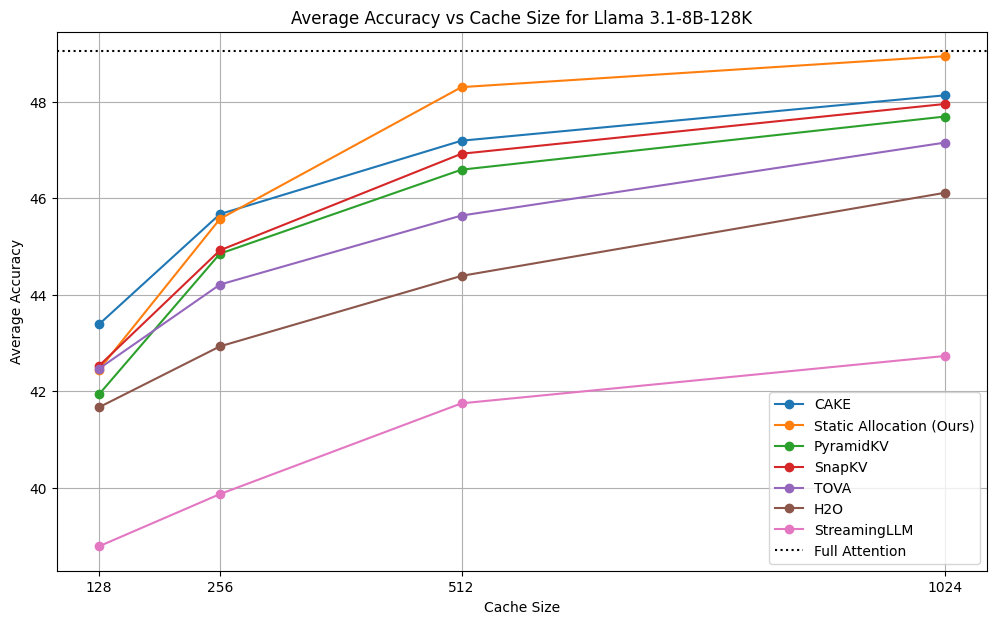

In [12]:
import matplotlib.pyplot as plt

cache_sizes = [128, 256, 512, 1024]
methods = [
    "cake_128", "cake_256", "cake_512", "cake_1024",
    "static_128", "static_256", "static_512", "static_1024",
    "PyramidKV_128", "PyramidKV_256", "PyramidKV_512", "PyramidKV_1024",
    "SnapKV_128", "SnapKV_256", "SnapKV_512", "SnapKV_1024",
    "TOVA_128", "TOVA_256", "TOVA_512", "TOVA_1024",
    "H2O_128", "H2O_256", "H2O_512", "H2O_1024",
    "StreamingLLM_128", "StreamingLLM_256", "StreamingLLM_512", "StreamingLLM_1024"
]

# Prepare average for each method at each cache size
method_labels = {
    "cake": "CAKE",
    "static": "Static Allocation (Ours)",
    "PyramidKV": "PyramidKV",
    "SnapKV": "SnapKV",
    "TOVA": "TOVA",
    "H2O": "H2O",
    "StreamingLLM": "StreamingLLM"
}

plt.figure(figsize=(12, 7))

# Plot one line per method family
for base in method_labels:
    vals = [df.loc[f"{base}_{cs}", "Avg."] for cs in cache_sizes if f"{base}_{cs}" in df.index]
    if vals:
        plt.plot(cache_sizes, vals, marker='o', label=method_labels[base])

plt.axhline(df.loc["full_attn", "Avg."], color='k', linestyle=':', label='Full Attention')

plt.xlabel("Cache Size")
plt.ylabel("Average Accuracy")
plt.title("Average Accuracy vs Cache Size for Llama 3.1-8B-128K")
plt.legend()
plt.xticks(cache_sizes)
plt.grid(True)
plt.show()


In [13]:

# Split full attention and method groups
full_attn = df.loc[['full_attn']]
rest = df.drop('full_attn')

group_dict = {
    '1024': [idx for idx in rest.index if '_1024' in idx],
    '512': [idx for idx in rest.index if '_512' in idx],
    '256': [idx for idx in rest.index if '_256' in idx],
    '128': [idx for idx in rest.index if '_128' in idx],
}

def highlight_max(df_group):
    formatted = df_group.copy()
    cols = df_group.columns
    for col in cols:
        # Find max in each column in this group (exclude full_attn)
        max_val = df_group[col].astype(float).max()
        for idx in df_group.index:
            if df_group.loc[idx, col] == max_val:
                # Bold only if not same as full attention
                if 'full_attn' not in idx:
                    formatted.loc[idx, col] = f'**{df_group.loc[idx, col]:.2f}**'
            else:
                formatted.loc[idx, col] = f'{df_group.loc[idx, col]:.2f}'
    return formatted

# Collect all rows to display, starting with full_attn
table_rows = [full_attn]
# For each group, highlight max
for size in ["1024", "512", "256", "128"]:
    group_df = df.loc[group_dict[size]]
    highlighted = highlight_max(group_df)
    table_rows.append(highlighted)

# Combine all together
final_df = pd.concat(table_rows)
final_df.insert(0, 'Method', final_df.index)
final_df = final_df.reset_index(drop=True)

# Output markdown table string
def df_to_markdown(tbl):
    # Header
    header = '| ' + ' | '.join(tbl.columns) + ' |'
    sep = '| ' + ' | '.join(['---'] * tbl.shape[1]) + ' |'
    lines = [header, sep]
    for _, row in tbl.iterrows():
        lines.append('| ' + ' | '.join(str(v) for v in row) + ' |')
    return '\n'.join(lines)

md_table = df_to_markdown(final_df)
print(md_table)

| Method | NrtvQA | Qasper | MF-en | HotpotQA | 2WikiMQA | Musique | GovReport | QMSum | MultiNews | TREC | TriviaQA | SAMSum | PCount | PR-en | Lcc | RB-P | Avg. |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| full_attn | 30.96 | 45.49 | 53.78 | 55.04 | 47.14 | 31.42 | 34.88 | 25.29 | 27.55 | 72.5 | 91.65 | 43.67 | 6.0 | 99.5 | 63.19 | 56.56 | 49.04 |
| cake_1024 | 30.88 | 44.95 | 52.38 | **55.49** | **46.99** | 30.82 | 28.68 | 24.91 | 26.39 | 69.00 | 91.94 | 42.60 | 6.00 | **99.50** | 62.65 | **56.89** | 48.13 |
| static_1024 | 29.84 | **45.93** | **53.78** | 55.04 | 46.63 | 30.92 | **34.64** | **25.35** | **27.52** | **73.00** | 91.65 | 43.53 | 6.00 | **99.50** | **63.33** | 56.34 | **48.94** |
| PyramidKV_1024 | 30.54 | 43.64 | 52.73 | 55.29 | 46.29 | **31.28** | 27.53 | 24.50 | 26.00 | 68.00 | **92.09** | 41.75 | 6.05 | **99.50** | 62.35 | 55.44 | 47.69 |
| SnapKV_1024 | **30.95** | 44.74 | 52.58 | 55.09 | 46.83 | 3

/tmp/ipykernel_2860576/216744646.py:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '30.88' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted.loc[idx, col] = f'{df_group.loc[idx, col]:.2f}'
/tmp/ipykernel_2860576/216744646.py:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '44.95' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted.loc[idx, col] = f'{df_group.loc[idx, col]:.2f}'
/tmp/ipykernel_2860576/216744646.py:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '52.38' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted.loc[idx, col] = f'{df_group.loc[idx, col]:.2f}'
/tmp/ipykernel_2860576/21

| Method | NrtvQA | Qasper | MF-en | HotpotQA | 2WikiMQA | Musique | GovReport | QMSum | MultiNews | TREC | TriviaQA | SAMSum | PCount | PR-en | Lcc | RB-P | Avg. |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| full_attn | 30.96 | 45.49 | 53.78 | 55.04 | 47.14 | 31.42 | 34.88 | 25.29 | 27.55 | 72.5 | 91.65 | 43.67 | 6.0 | 99.5 | 63.19 | 56.56 | 49.04 |
| cake_1024 | 30.88 | 44.95 | 52.38 | **55.49** | **46.99** | 30.82 | 28.68 | 24.91 | 26.39 | 69.00 | 91.94 | 42.60 | 6.00 | **99.50** | 62.65 | **56.89** | 48.13 |
| static_1024 | 29.84 | **45.93** | **53.78** | 55.04 | 46.63 | 30.92 | **34.64** | **25.35** | **27.52** | **73.00** | 91.65 | 43.53 | 6.00 | **99.50** | **63.33** | 56.34 | **48.94** |
| PyramidKV_1024 | 30.54 | 43.64 | 52.73 | 55.29 | 46.29 | **31.28** | 27.53 | 24.50 | 26.00 | 68.00 | **92.09** | 41.75 | 6.05 | **99.50** | 62.35 | 55.44 | 47.69 |
| SnapKV_1024 | **30.95** | 44.74 | 52.58 | 55.09 | 46.83 | 30.37 | 27.87 | 24.57 | 25.99 | 68.00 | 92.03 | 42.60 | **6.50** | **99.50** | 63.00 | 56.50 | 47.95 |
| TOVA_1024 | 30.66 | 40.95 | 51.09 | 54.58 | 46.51 | 30.62 | 28.12 | 23.61 | 26.24 | 68.00 | 91.49 | **43.80** | 5.92 | **99.50** | 60.73 | 52.64 | 47.15 |
| H2O_1024 | 29.57 | 36.15 | 45.94 | 54.43 | 44.81 | 29.04 | 27.64 | 23.31 | 26.47 | 62.00 | 91.83 | 43.14 | 6.36 | 99.00 | 62.74 | 55.39 | 46.11 |
| StreamingLLM_1024 | 26.64 | 30.77 | 35.59 | 47.31 | 42.03 | 24.17 | 25.81 | 21.31 | 25.66 | 63.50 | 88.84 | 42.76 | **6.50** | 88.00 | 61.36 | 53.47 | 42.73 |
| cake_512 | **31.82** | 42.99 | 51.65 | 54.37 | **46.89** | **30.73** | 26.36 | **24.94** | 25.27 | 63.50 | 91.54 | 42.52 | 6.33 | **99.50** | 62.31 | 54.30 | 47.19 |
| static_512 | 29.03 | **45.38** | **53.78** | 54.03 | 46.60 | 28.97 | **33.37** | 23.59 | **27.47** | **73.00** | 91.01 | 43.02 | 6.00 | **99.50** | **63.25** | 54.78 | **48.30** |
| PyramidKV_512 | 30.47 | 42.15 | 52.17 | **54.67** | 45.25 | 30.60 | 25.00 | 24.33 | 24.51 | 62.50 | 91.24 | 41.67 | 5.95 | **99.50** | 61.58 | 53.89 | 46.59 |
| SnapKV_512 | 30.76 | 42.03 | 52.13 | 54.15 | 46.14 | 30.51 | 24.98 | 24.24 | 24.65 | 64.00 | **92.05** | 42.04 | 6.08 | **99.50** | 62.62 | **54.90** | 46.92 |
| StreamingLLM_512 | 25.64 | 27.48 | 33.30 | 47.36 | 40.06 | 24.80 | 23.16 | 20.80 | 22.85 | 57.50 | 87.69 | 42.08 | **6.50** | 97.00 | 60.51 | 51.28 | 41.75 |
| H2O_512 | 27.76 | 29.01 | 44.75 | 52.78 | 44.31 | 29.22 | 24.71 | 23.11 | 24.56 | 54.50 | 91.38 | 42.10 | 6.36 | 99.00 | 62.30 | 54.33 | 44.39 |
| TOVA_512 | 30.11 | 35.77 | 49.88 | 54.58 | 45.86 | 29.73 | 25.45 | 22.73 | 25.00 | 63.50 | 91.90 | **43.33** | 6.00 | **99.50** | 58.38 | 48.58 | 45.64 |
| cake_256 | **29.75** | 38.74 | **52.27** | 54.52 | 45.39 | 29.57 | 24.15 | **24.24** | 23.77 | 57.00 | 90.97 | 41.82 | 6.10 | **99.50** | 61.01 | 51.90 | **45.67** |
| static_256 | 27.73 | **43.99** | 48.03 | 51.33 | 44.66 | 28.02 | **26.77** | 20.98 | **27.29** | **61.00** | 88.17 | 41.70 | **6.50** | **99.50** | **62.23** | 51.22 | 45.57 |
| StreamingLLM_256 | 23.57 | 24.73 | 30.31 | 46.42 | 39.19 | 24.23 | 20.61 | 21.10 | 19.46 | 45.50 | 87.50 | 41.01 | **6.50** | **99.50** | 59.55 | 48.70 | 39.87 |
| H2O_256 | 25.93 | 27.16 | 43.86 | 52.23 | 43.20 | 28.28 | 22.10 | 22.37 | 22.75 | 47.50 | 91.23 | 41.99 | 6.28 | 99.00 | 61.02 | 52.02 | 42.93 |
| TOVA_256 | 29.70 | 30.85 | 48.80 | 54.36 | **46.71** | **30.00** | 23.21 | 22.18 | 22.88 | 57.50 | **91.83** | **42.77** | 6.05 | **99.50** | 54.83 | 46.15 | 44.21 |
| SnapKV_256 | 27.22 | 35.25 | 50.96 | 54.50 | 45.73 | 28.56 | 22.75 | 23.80 | 22.83 | 55.50 | 91.28 | 41.42 | 6.03 | **99.50** | 60.64 | **52.80** | 44.92 |
| PyramidKV_256 | 28.73 | 36.14 | 51.01 | **54.57** | 44.55 | 29.58 | 22.68 | 23.33 | 22.34 | 56.00 | 90.37 | 41.09 | 6.25 | **99.50** | 60.03 | 51.45 | 44.85 |
| cake_128 | 27.41 | **32.01** | **49.58** | 52.99 | **45.76** | 28.32 | 21.85 | **23.15** | 21.56 | 47.50 | 89.61 | 40.90 | 6.33 | **99.50** | 57.92 | 49.83 | **43.39** |
| static_128 | 26.33 | 29.31 | 44.04 | 50.71 | 42.61 | 28.02 | **22.91** | 19.89 | **26.61** | **59.50** | 77.75 | 38.10 | 6.50 | **99.50** | **59.56** | 47.88 | 42.45 |
| StreamingLLM_128 | 23.01 | 22.50 | 31.00 | 46.79 | 40.52 | 24.76 | 18.38 | 20.89 | 16.96 | 40.50 | 86.00 | 38.55 | **7.00** | **99.50** | 57.06 | 47.16 | 38.79 |
| H2O_128 | 26.18 | 24.83 | 44.08 | 51.33 | 43.29 | 27.78 | 20.79 | 22.36 | 20.69 | 41.50 | 89.88 | 40.94 | 6.20 | 99.00 | 58.12 | 49.82 | 41.67 |
| TOVA_128 | **29.44** | 27.03 | 45.20 | **54.15** | 44.87 | **28.87** | 22.21 | 20.54 | 20.52 | 53.50 | **92.27** | **40.99** | 6.17 | **99.50** | 51.14 | 43.15 | 42.47 |
| SnapKV_128 | 26.40 | 27.67 | 47.83 | 53.40 | 44.20 | 28.68 | 20.56 | 23.11 | 20.13 | 45.50 | 89.36 | 39.98 | 6.33 | 99.00 | 57.69 | **50.69** | 42.53 |
| PyramidKV_128 | 25.57 | 27.40 | 46.36 | 53.14 | 44.51 | 27.16 | 20.74 | 22.26 | 19.90 | 45.50 | 87.06 | 40.13 | 6.50 | **99.50** | 56.98 | 48.26 | 41.94 |

In [15]:
# Ensure table has no markdown formatting
final_df_plain = final_df.replace(r"\*\*", "", regex=True)

# Save as CSV in your current directory
final_df_plain.to_csv("results_table.csv", index=False)

print("CSV exported as 'results_table.csv'. You can upload/import this in Excel or Sheets.")


CSV exported as 'results_table.csv'. You can upload/import this in Excel or Sheets.


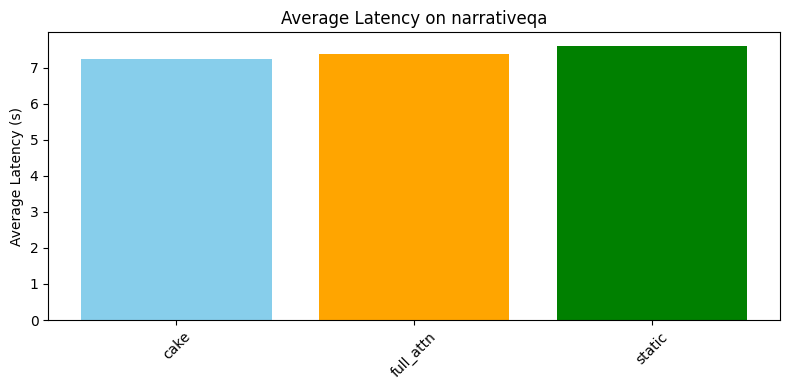

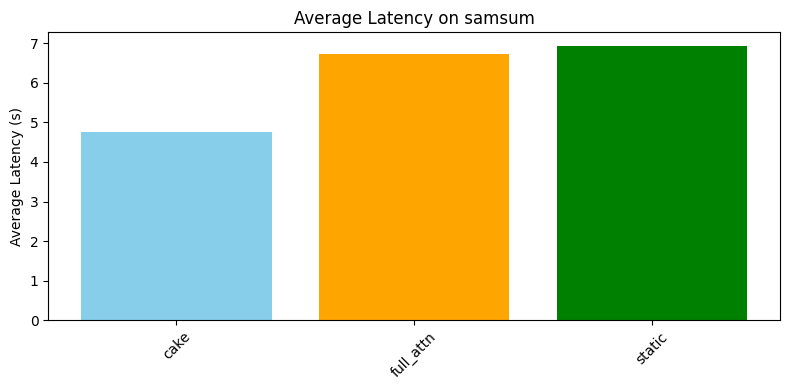

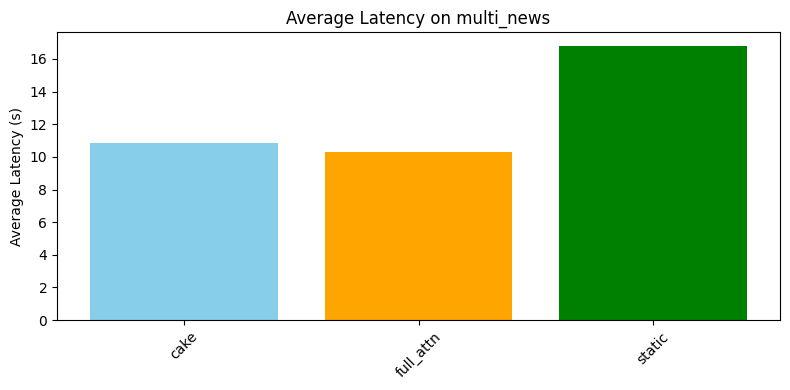

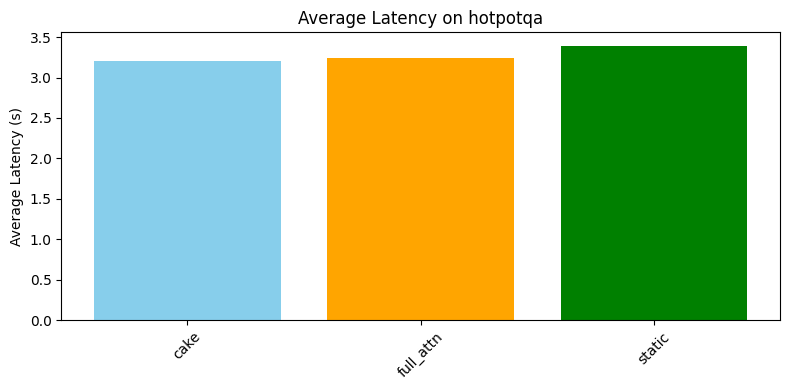

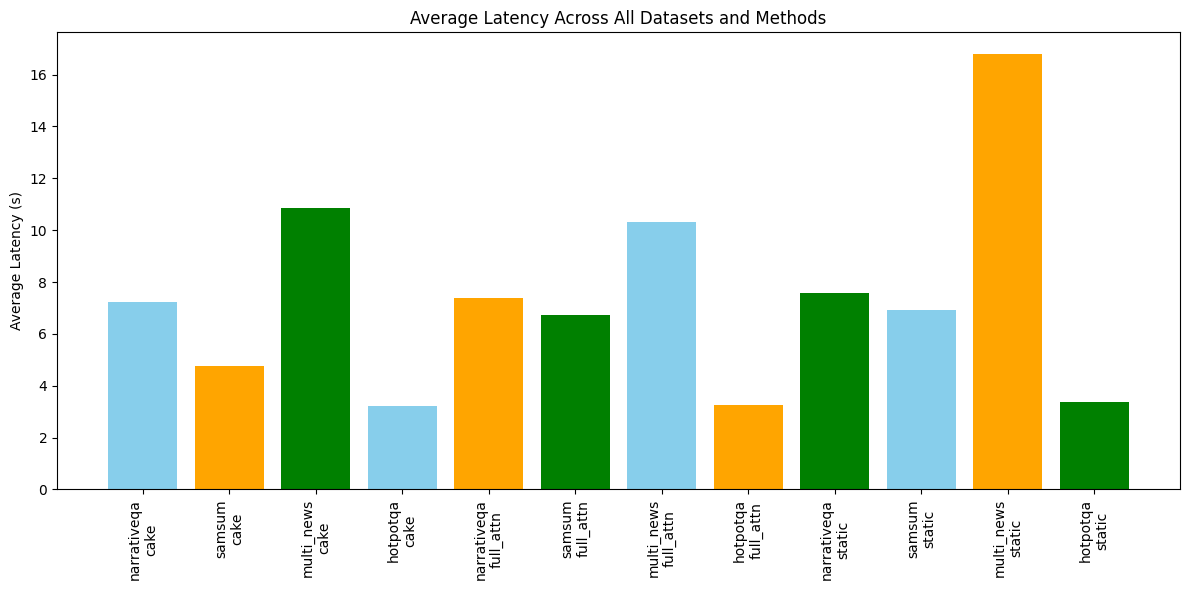

In [6]:
import os
import json
import matplotlib.pyplot as plt
from collections import defaultdict

def gather_average_latencies(root_dir):
    avg_latency = {}  # {(dataset, method): average_latency}
    for dirpath, _, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith('_latencies.jsonl'):
                filepath = os.path.join(dirpath, filename)
                # Set method explicitly based on major folder name
                if 'cakekv' in dirpath:
                    method = 'static'
                elif 'cake_original' in dirpath:
                    method = 'cake'
                elif 'full_attn_benchmark' in dirpath:
                    method = 'full_attn'
                else:
                    method = os.path.basename(dirpath)
                dataset = filename.replace('_latencies.jsonl', '')
                avg = None
                with open(filepath, 'r', encoding='utf-8') as f:
                    for line in f:
                        entry = json.loads(line.strip())
                        if entry.get('sample_num') == 'average':
                            avg = entry['latency']
                if avg is not None:
                    avg_latency[(dataset, method)] = avg
    return avg_latency

root_dir = "/home/am233354/"
avg_latency = gather_average_latencies(root_dir)

# Organize by dataset for plotting
dataset_to_methods = defaultdict(dict)
for (dataset, method), latency in avg_latency.items():
    dataset_to_methods[dataset][method] = latency

# Plot a chart per dataset
for dataset, method_latencies in dataset_to_methods.items():
    methods = list(method_latencies.keys())
    latencies = [method_latencies[m] for m in methods]
    plt.figure(figsize=(8, 4))
    plt.bar(methods, latencies, color=['skyblue', 'orange', 'green'][:len(methods)])
    plt.ylabel('Average Latency (s)')
    plt.title(f'Average Latency on {dataset}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Optionally: Plot one global chart of all (dataset, method) pairs
plt.figure(figsize=(12, 6))
labels = [f"{d}\n{m}" for (d, m) in avg_latency]
values = [avg_latency[(d, m)] for (d, m) in avg_latency]
plt.bar(labels, values, color=['skyblue', 'orange', 'green'] * (len(labels)//3 + 1))
plt.ylabel('Average Latency (s)')
plt.title('Average Latency Across All Datasets and Methods')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


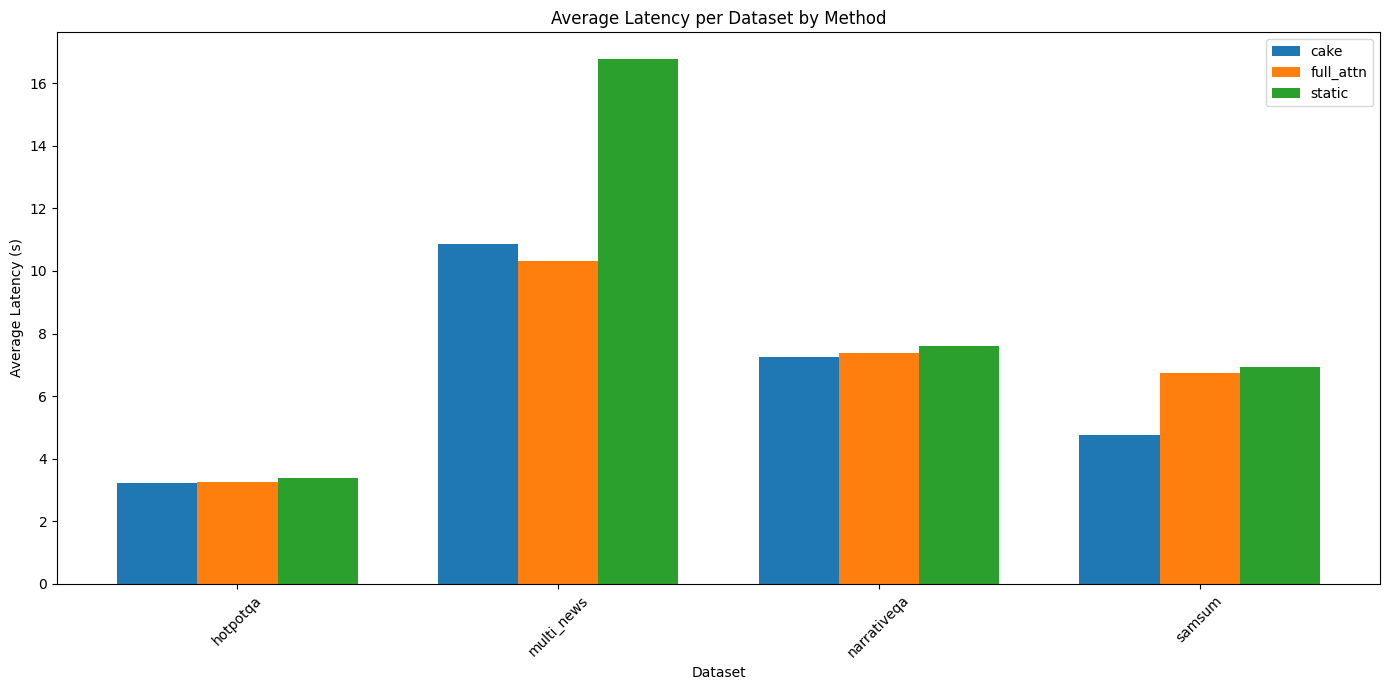

In [9]:
import os
import json
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np

def gather_average_latencies(root_dir):
    avg_latency = {}  # {(dataset, method): average_latency}
    for dirpath, _, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith('_latencies.jsonl'):
                filepath = os.path.join(dirpath, filename)
                if 'cakekv' in dirpath:
                    method = 'static'
                elif 'cake_original' in dirpath:
                    method = 'cake'
                elif 'full_attn_benchmark' in dirpath:
                    method = 'full_attn'
                else:
                    method = os.path.basename(dirpath)
                dataset = filename.replace('_latencies.jsonl', '')
                avg = None
                with open(filepath, 'r', encoding='utf-8') as f:
                    for line in f:
                        entry = json.loads(line.strip())
                        if entry.get('sample_num') == 'average':
                            avg = entry['latency']
                if avg is not None:
                    avg_latency[(dataset, method)] = avg
    return avg_latency

root_dir = "/home/am233354/"  # Change this to your root folder
avg_latency = gather_average_latencies(root_dir)

# Arrange data for plotting
method_to_dataset_latency = defaultdict(dict)
for (dataset, method), latency in avg_latency.items():
    method_to_dataset_latency[method][dataset] = latency

all_datasets = set()
for dataset_dict in method_to_dataset_latency.values():
    all_datasets.update(dataset_dict.keys())
sorted_datasets = sorted(all_datasets)
methods = sorted(method_to_dataset_latency.keys())

bar_width = 0.25
index = np.arange(len(sorted_datasets))

plt.figure(figsize=(14, 7))
for i, method in enumerate(methods):
    latencies = [method_to_dataset_latency[method].get(ds, 0) for ds in sorted_datasets]
    plt.bar(index + i * bar_width, latencies, bar_width, label=method)
plt.xlabel('Dataset')
plt.ylabel('Average Latency (s)')
plt.title('Average Latency per Dataset by Method')
plt.xticks(index + bar_width * (len(methods) - 1) / 2, sorted_datasets, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


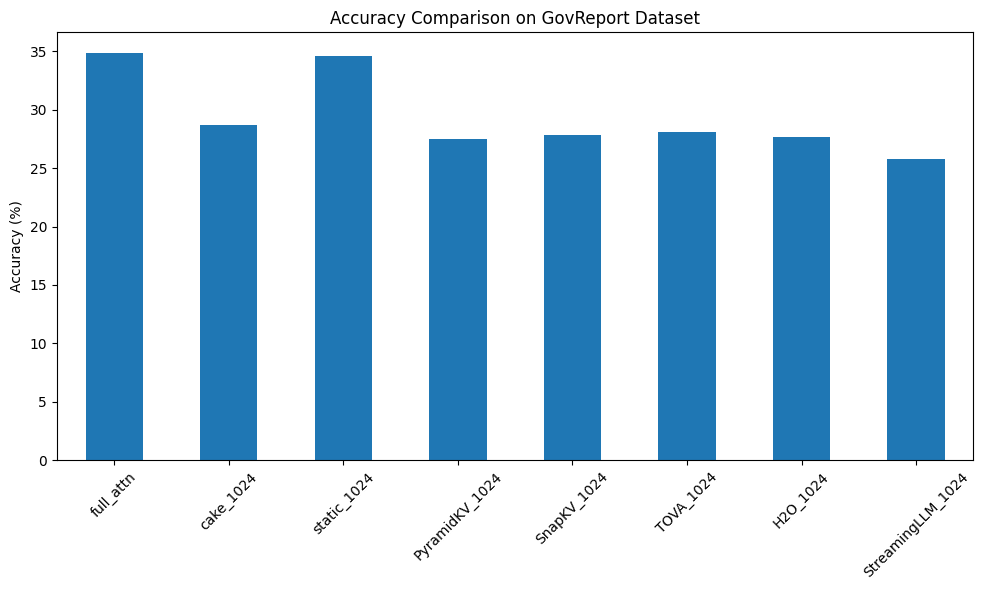

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset and methods
datasets = ["NrtvQA", "Qasper", "MF-en", "HotpotQA", "2WikiMQA", "Musique",
            "GovReport", "QMSum", "MultiNews", "TREC", "TriviaQA", "SAMSum",
            "PCount", "PR-en", "Lcc", "RB-P", "Avg."]

data = {
    'full_attn': [30.96, 45.49, 53.78, 55.04, 47.14, 31.42, 34.88, 25.29, 27.55, 72.5, 91.65, 43.67, 6, 99.5, 63.19, 56.56, 49.04],
    'cake_1024': [30.88, 44.95, 52.38, 55.49, 46.99, 30.82, 28.68, 24.91, 26.39, 69, 91.94, 42.6, 6, 99.5, 62.65, 56.89, 48.13],
    'static_1024': [29.84, 45.93, 53.78, 55.04, 46.63, 30.92, 34.64, 25.35, 27.52, 73, 91.65, 43.53, 6, 99.5, 63.33, 56.34, 48.94],
    'PyramidKV_1024': [30.54, 43.64, 52.73, 55.29, 46.29, 31.28, 27.53, 24.50, 26.00, 68.00, 92.09, 41.75, 6.05, 99.50, 62.35, 55.44, 47.69],
    'SnapKV_1024': [30.95, 44.74, 52.58, 55.09, 46.83, 30.37, 27.87, 24.57, 25.99, 68.00, 92.03, 42.60, 6.50, 99.50, 63.00, 56.50, 47.95],
    'TOVA_1024': [30.66, 40.95, 51.09, 54.58, 46.51, 30.62, 28.12, 23.61, 26.24, 68.00, 91.49, 43.80, 5.92, 99.50, 60.73, 52.64, 47.15],
    'H2O_1024': [29.57, 36.15, 45.94, 54.43, 44.81, 29.04, 27.64, 23.31, 26.47, 62.00, 91.83, 43.14, 6.36, 99.00, 62.74, 55.39, 46.11],
    'StreamingLLM_1024': [26.64, 30.77, 35.59, 47.31, 42.03, 24.17, 25.81, 21.31, 25.66, 63.50, 88.84, 42.76, 6.50, 88.00, 61.36, 53.47, 42.73]
}

accuracy_df = pd.DataFrame.from_dict(data, orient='index', columns=datasets)

# Extract only GovReport column
govreport_scores = accuracy_df['GovReport']

# Plotting
plt.figure(figsize=(10,6))
govreport_scores.plot(kind='bar')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Comparison on GovReport Dataset')
plt.xticks(rotation=45)
# plt.grid(axis='y')
plt.tight_layout()
plt.show()
